# **Clustering Model Training Notebook**



---
## Setup Environment

In [1336]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [1337]:
group_name = "Group 24"
student_name = "Shameel Zeshan Khader Sheriff"
student_id = "26030371"

In [1338]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [1339]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [1340]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [1341]:
# No aditional package to be installed

### 0.b Import Packages

In [1342]:
# <Student to fill this section>
import pandas as pd
import altair as alt

In [1343]:
# additional package to import
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## A. Experiment Description

### Experiment Hypothesis 1

In [1344]:
experiment_hypothesis_1 = """
Hypothesis:
Sold products can be segmented into distinct and actionable product portfolio groups using
product-level demand, revenue, realised price, margin, promotion eligibility, actual promotion
usage, and historical price/cost movement features. If the clustering approach is suitable, the
final clusters should reveal different commercial roles that support margin-aware promotion
decisions, such as identifying products that need discount controls, products suitable for
cross-sell and bundle strategies, products requiring demand support or range review, products
with volatile cost and price histories that need pre-promotion review, and products that require
price integrity protection.

Testable expectation:
If the hypothesis holds, the final cluster solution should include at least one segment with
clearly above-average promotional realisation and below-average gross margin percentage, and at
least one segment with above-average gross margin percentage and minimal promotional activity.
This cross-cluster contrast would confirm that the model has captured different combinations of
promotion exposure and margin position, creating commercially meaningful product groups that can
support different promotion decisions.
"""

In [1345]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis_1', value=experiment_hypothesis_1)

### Experiment Hypothesis 2

In [1346]:
experiment_hypothesis_2 = """
Hypothesis:
A product-level clustering model can identify 4 to 6 viable and interpretable sold-product
segments that are commercially distinct across demand frequency, revenue contribution, realised
price, gross margin percentage, promotion eligibility, actual promotion usage, and historical
price/cost movement.

For the clustering outcome to be useful, the segments must support different margin-aware
promotion actions. Specifically, the model should separate products that are heavily discounted
with weaker margin from products that maintain strong margin without relying heavily on promotions,
and should further distinguish products with stable pricing from those with volatile cost and price
histories.

Testable expectation:
If the hypothesis holds, the selected cluster count should fall within the 4 to 6 range, each
cluster should contain a sufficient number of products to be commercially actionable, and no single
cluster should capture more than half the portfolio. The clusters should be distinguishable from
each other on at least three of the five key business dimensions: demand activity, margin position,
promotional realisation, unit price, and price or cost stability. A solution that collapses the
portfolio into fewer than four groups or produces one dominant catch-all segment would not satisfy
this hypothesis.
"""

In [1347]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis_2', value=experiment_hypothesis_2)

---
## B. Business Understanding

In [1348]:
business_use_case_description = """
The goal of this project is to build a product portfolio segmentation model for margin-aware promotion decision support.

The retailer wants to understand whether sold products naturally group into different commercial roles based on demand, sales value, margin position, promotion eligibility, realised promotion usage, and historical price/cost movement. Because there is no existing product segment label, this is framed as an unsupervised clustering problem.

The business objective is not to predict a known outcome, but to discover product groups that can support merchandising and promotion planning. For example, the model may help identify products that should be protected from unnecessary discounting, products that are promotion-sensitive, high-value products that need careful margin management, and low-activity products that may require range or pricing review.

The final output will be a set of interpretable product clusters with business profiles and recommended promotion actions for each cluster.
"""

In [1349]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [1350]:
business_objectives = """
The primary objective is to discover product groups that support differentiated promotion and
merchandising decisions. If the clusters are meaningful, the merchandising team can identify
products with similar demand, margin, and promotion behaviour and apply distinct strategies to
each group. For example, high-margin products with low promotion need can be protected from
unnecessary discounting, while products with weak demand or high promotion reliance can be
reviewed for pricing, bundling, or range decisions.

The business impact of useful clusters is improved promotion efficiency, better margin protection,
clearer product portfolio review, and more targeted merchandising actions. The model can also
reduce manual analysis effort by summarising 254 sold products into a smaller number of
interpretable product groups.

Incorrect or poorly interpreted clusters could lead to harmful business decisions. Products may
be discounted unnecessarily, reducing margin on items that do not need promotional support, or
products that genuinely benefit from promotion may be overlooked. If clusters reflect only
mathematical separation rather than commercial meaning, the resulting recommendations may be
misleading. For this reason, the final model must be assessed using both internal clustering
metrics and business interpretability — a technically valid cluster solution that cannot be
described in commercial terms will not satisfy the objective of this project.
"""

In [1351]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [1352]:
stakeholders_expectations_explanations = """
The main users of the clustering results are merchandising, pricing, promotion, and product portfolio managers. They can use the cluster profiles to understand groups of products with similar commercial behaviour and decide which products may need discount protection, targeted promotional support, pricing review, or further range analysis.

The results will be used as a decision-support tool rather than an automated decision system. Cluster labels should help stakeholders prioritise investigation and planning, but final promotion or pricing decisions should still include business judgement, stock context, supplier constraints, seasonality, and campaign objectives.

The parties impacted by the model include the retailer, product teams, stores or sales channels, suppliers, and customers. The retailer may benefit through improved margin and promotion efficiency. Customers may be affected through changes in promotional offers or product availability. Suppliers may also be indirectly affected if cluster insights influence ordering, promotion support, or range review decisions.

Because the model uses product-level and transaction-derived behaviour rather than personal customer attributes, the privacy risk is lower than in customer segmentation. However, ethical care is still required because incorrect interpretation could lead to unfair or excessive discounting decisions, reduced product variety, or poor customer value.
"""

In [1353]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [1354]:
# Load data
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')

except Exception as e:
  print(e)

### C.2 Define Target variable

In [1355]:
target_summary_df = pd.DataFrame({
    "item": [
        "Data mining problem",
        "Target variable",
        "Reason",
        "Model output"
    ],
    "description": [
        "Clustering / unsupervised learning",
        "Not applicable",
        "There is no predefined product segment label in the dataset.",
        "Cluster labels generated by the model after fitting."
    ]
})

target_summary_df

,item,description
0,Data mining problem,Clustering / unsupervised learning
1,Target variable,Not applicable
2,Reason,There is no predefined product segment label i...
3,Model output,Cluster labels generated by the model after fi...


In [1356]:
target_definition_explanations = """
No target variable is defined for this project because the selected data mining problem is clustering.

In classification or regression, the model learns from a known target variable and attempts to predict that outcome. In this use case, the retailer does not already have labelled product segments such as "high-margin product", "promotion-sensitive product", or "low-activity product". The objective is to discover these product groups from the prepared product-level features.

Therefore, all numeric commercial features are treated as inputs for measuring similarity between products. The model output will be a cluster label assigned after training, not a prediction of a pre-existing target variable.
"""

In [1357]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [1358]:
target_name = None

### C.4 Explore Target variable

In [1359]:
target_distribution_explanations = """
Target distribution analysis is not applicable because this is an unsupervised clustering task with no target variable.

There are no known product segment labels to count or compare before modelling. Instead, the distribution of model-generated cluster labels will be analysed after fitting the clustering models. At that later stage, cluster size balance will be reviewed to check whether the segmentation is useful for business interpretation.
"""

In [1360]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `gross_margin_pct`

In [1361]:
feature_1_name = "gross_margin_pct"

feature_1_summary_df = X_train[feature_1_name].describe().to_frame().T
feature_1_summary_df

,count,mean,std,min,25%,50%,75%,max
gross_margin_pct,254.0,2.578865e-16,1.001974,-2.364354,-0.85996,-0.164635,0.860053,1.552422


In [1362]:
alt.Chart(X_train).mark_bar().encode(
    x=alt.X(f"{feature_1_name}:Q", bin=alt.Bin(maxbins=30), title="Scaled gross_margin_pct"),
    y=alt.Y("count():Q", title="Number of Products"),
    tooltip=["count()"]
).properties(
    title="Distribution of Scaled Gross Margin Percentage",
    width=600,
    height=350
)

alt.Chart(...)

In [1363]:
feature_1_insights = """
The first feature explored is gross_margin_pct, which represents each product's relative margin
position based on list price and standard cost. This feature has already been standardised in the
prepared modelling dataset. The mean is approximately 0 and the standard deviation is approximately
1. Positive values represent products with above-average margin percentage, while negative values
represent products with below-average margin percentage.

The distribution is bimodal rather than unimodal. A large concentration of products sits between
-1.2 and -0.8 standard deviations from the mean, and a second large concentration sits between
0.8 and 1.6, with relatively few products in the middle range. A small number of products sits below
-2.0, representing products with extremely compressed margins. This bimodal shape suggests the
portfolio naturally separates into lower-margin and higher-margin groups, which provides early
evidence that clustering may produce commercially distinct margin tiers rather than an arbitrary
partition of a uniform distribution.

This feature is important for the selected business use case because the clustering model should
not group products only by demand or sales value. Margin position is central to margin-aware
promotion decisions. Products with lower margin may be more vulnerable to excessive discounting,
while products with stronger margin may allow more promotional flexibility or require discount
protection depending on their demand and promotion behaviour.

A limitation is that this feature is based on list price and standard cost, so it does not capture
all real-world profitability factors such as fulfilment costs, supplier rebates, stock holding
costs, or campaign costs. It should therefore be interpreted as an estimated product margin signal
rather than a complete profit measure.
"""

In [1364]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `total_sales_value`

In [1365]:
feature_2_name = "total_sales_value"

feature_2_summary_df = X_train[feature_2_name].describe().to_frame().T
feature_2_summary_df

,count,mean,std,min,25%,50%,75%,max
total_sales_value,254.0,1.442416e-16,1.001974,-2.956117,-0.715257,-0.036055,0.708614,2.020034


In [1366]:
alt.Chart(X_train).mark_bar().encode(
    x=alt.X(f"{feature_2_name}:Q", bin=alt.Bin(maxbins=30), title="Scaled total_sales_value"),
    y=alt.Y("count():Q", title="Number of Products"),
    tooltip=["count()"]
).properties(
    title="Distribution of Scaled Total Sales Value",
    width=600,
    height=350
)

alt.Chart(...)

In [1367]:
feature_2_insights = """
The second feature explored is total_sales_value, which represents each product's total revenue
contribution aggregated across all historical order lines. This feature was log-transformed and
standardised in SD-a. Values above 0 represent above-average transformed sales revenue, while
values below 0 represent below-average transformed sales revenue.

The distribution is approximately unimodal and roughly symmetric after transformation, with the
peak centred near -0.2. The range extends from -2.96 to +2.02 with a median of -0.04, indicating
that the centre of the distribution sits very close to the mean. A small left tail exists below
-2.0, representing a small number of very low-revenue products. The right tail extends to
approximately +2.0, representing the highest-revenue products in the portfolio.

This shape contrasts with gross_margin_pct, which showed a bimodal distribution suggesting
natural margin tiers. total_sales_value does not show strong multimodality on its own, meaning
revenue level alone is unlikely to be the primary driver of cluster separation. Instead, it will
interact with margin and promotion features to contribute to commercial archetypes. For example,
a high-revenue product with low margin and heavy discounting represents a different commercial
risk from a high-revenue product with strong margin and minimal promotion.

A limitation is that total_sales_value reflects historical transaction volume and price combined.
Two products with similar total sales value may have achieved that outcome through different
routes: one through high volume at low price, another through lower volume at higher price. For
this reason, total_sales_value is interpreted alongside order_line_count, avg_unit_price, margin,
and promotion features rather than as a standalone revenue signal.
"""

In [1368]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `promotional_order_line_share`


In [1369]:
feature_n_name = "promotional_order_line_share"

feature_n_summary_df = X_train[feature_n_name].describe().to_frame().T
feature_n_summary_df

,count,mean,std,min,25%,50%,75%,max
promotional_order_line_share,254.0,1.223868e-16,1.001974,-0.429332,-0.429332,-0.429332,-0.091209,9.673852


In [1370]:
alt.Chart(X_train).mark_bar().encode(
    x=alt.X(f"{feature_n_name}:Q", bin=alt.Bin(maxbins=30), title="Scaled promotional_order_line_share"),
    y=alt.Y("count():Q", title="Number of Products"),
    tooltip=["count()"]
).properties(
    title="Distribution of Scaled Promotional Order Line Share",
    width=600,
    height=350
)

alt.Chart(...)

In [1371]:
feature_3_insights = """
The third feature explored is promotional_order_line_share, which measures the proportion of a
product's historical order lines where a promotional offer was applied at the point of transaction.
This feature was standardised in SD-a. The floor value of -0.429 corresponds to a raw proportion
of zero, meaning no order lines for that product used a promotional offer.

The distribution is severely right-skewed and zero-inflated. The minimum, 25th percentile, and
median all sit at -0.429, indicating that more than half of the 254 sold products had zero
promotional order line share. In other words, many products were never purchased through a
promotional offer across the recorded transactions. The 75th percentile is only -0.091, meaning
at least three quarters of products have very low promotional uptake. The distribution then has
a long right tail reaching a maximum of 9.67 standard deviations above the mean, representing a
very small number of products with unusually high promotional usage.

This zero-inflation has two implications. First, it confirms that promotional activity is highly
concentrated in a small subset of products. The majority of the portfolio receives little or no
promotional order line engagement, which is commercially significant because these products may
be less promotion-dependent, under-promoted, or mainly sold through regular-price behaviour.
Second, the extreme right tail could disproportionately influence distance-based clustering if
the model relies too heavily on this feature.

For this reason, promotional_order_line_share will be reviewed alongside discounted_line_share
and max_actual_discount_pct during feature selection. These features all describe realised
discount or promotion behaviour, so the final feature set should retain enough promotional
information for business interpretation without allowing repeated or extreme promotion signals
to dominate the clustering solution.
"""

In [1372]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Feature Selection


In [1373]:
# D.1 Separate Profile Columns From Candidate Numeric Features

profile_columns = [
    "product_id",
    "product_name",
    "product_number",
    "category_name",
    "subcategory_name",
    "product_line",
    "class",
    "style",
    "color"
]

candidate_features = [
    col for col in X_train.columns
    if col not in profile_columns
]

candidate_feature_summary_df = pd.DataFrame({
    "feature_group": ["Profile columns", "Candidate numeric clustering features"],
    "feature_count": [len(profile_columns), len(candidate_features)],
    "features": [", ".join(profile_columns), ", ".join(candidate_features)]
})

candidate_feature_summary_df

,feature_group,feature_count,features
0,Profile columns,9,"product_id, product_name, product_number, cate..."
1,Candidate numeric clustering features,18,"order_line_count, total_quantity, total_sales_..."


In [1374]:
feature_selection_step_1_explanations = """
The first feature selection step separates profile columns from candidate numeric clustering
features.

Profile columns such as product_id, product_name, product_number, category_name,
subcategory_name, product_line, class, style, and color are retained in the dataset for cluster
interpretation and reporting. They help explain which products belong to each cluster after the
model assigns cluster labels. However, they are not used as clustering inputs because identifiers
and text/category descriptors do not directly measure behavioural similarity between products.

The candidate numeric clustering features are the transformed and scaled variables that describe
product demand, revenue, price, margin, promotion behaviour, and historical price/cost movement.
These are appropriate for K-Means because the algorithm calculates distances between numeric
feature values.

This separation is important because it keeps the modelling input focused on measurable commercial
behaviour, while still preserving product and hierarchy information for business interpretation
after clustering.
"""

In [1375]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_step_1_explanations', value=feature_selection_step_1_explanations)

In [1376]:
# D.2 Review Redundancy Among Candidate Numeric Features

numeric_correlation_df = X_train[candidate_features].corr().abs()

high_correlation_pairs = []

for i, feature_1 in enumerate(candidate_features):
    for feature_2 in candidate_features[i + 1:]:
        corr_value = numeric_correlation_df.loc[feature_1, feature_2]
        if corr_value >= 0.85:
            high_correlation_pairs.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "absolute_correlation": corr_value
            })

high_correlation_pairs_df = (
    pd.DataFrame(high_correlation_pairs)
    .sort_values("absolute_correlation", ascending=False)
    .reset_index(drop=True)
)

high_correlation_pairs_df

,feature_1,feature_2,absolute_correlation
0,list_price,standard_cost,0.996821
1,list_price,gross_margin_amount,0.992870
2,avg_unit_price,list_price,0.992466
3,avg_unit_price,standard_cost,0.990620
4,avg_unit_price,gross_margin_amount,0.983725
5,avg_line_value,list_price,0.983263
6,standard_cost,gross_margin_amount,0.980873
7,avg_line_value,standard_cost,0.978483
8,avg_line_value,gross_margin_amount,0.976510
9,avg_line_value,avg_unit_price,0.965175


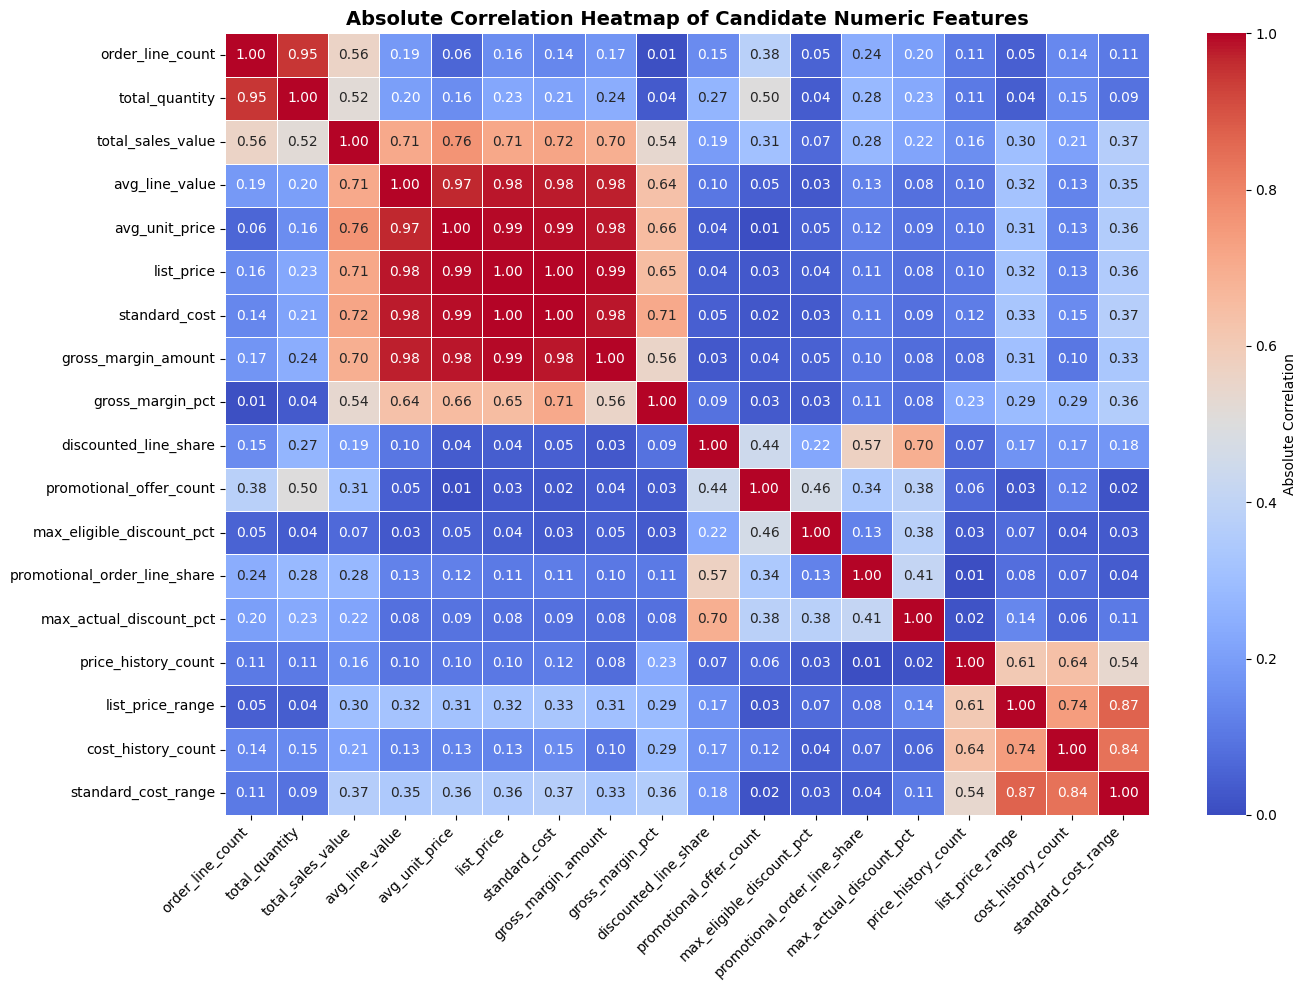

In [1377]:
# D.2 Visualise Correlation Between Candidate Numeric Features

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_correlation_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Absolute Correlation"}
)

plt.title("Absolute Correlation Heatmap of Candidate Numeric Features", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [1378]:
feature_selection_step_2_explanations = """
The correlation review is used to make the clustering input more suitable for the product portfolio
segmentation use case.

For this project, the model should separate products using distinct commercial signals: demand
frequency, revenue contribution, realised price, margin percentage, promotion behaviour, and
historical price/cost movement. The heatmap shows that some candidate features repeat the same
signal. In a K-Means model, repeated signals can dominate the distance calculation and make
clusters reflect one business dimension too strongly.

The main issue is the price and margin-value block. list_price, standard_cost,
gross_margin_amount, avg_unit_price, and avg_line_value are all highly correlated, mostly above
0.96. If all of them are kept, the clustering model may mainly separate expensive products from
cheap products rather than identifying useful promotion and margin decision groups. For this use
case, avg_unit_price is retained from this block as the representative price signal because it
reflects the actual realised selling price rather than the catalogue list price. gross_margin_pct
is retained separately as the margin proportion signal because it measures a distinct commercial
dimension for margin-aware promotion decisions.

The second issue is demand duplication. order_line_count and total_quantity have an absolute
correlation of approximately 0.95. For this business use case, order_line_count is retained because
it measures how frequently a product appears in transactions. This is more useful for promotion
planning than total_quantity, which can be inflated by bulk purchases or larger order quantities.

The historical movement features also show some correlation, especially list_price_range and
standard_cost_range. This pair is retained as an explicit business exception to the 0.85 screening
threshold. The reason is that these features describe different risks: list_price_range captures
pricing movement, while standard_cost_range captures cost movement. Both can affect margin-aware
promotion decisions, and these historical movement signals are not strongly represented elsewhere
in the final feature set.

Therefore, the next step removes the most redundant demand, price, cost, and margin amount features
while preserving the commercial signals needed for margin-aware promotion segmentation.
"""

In [1379]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_step_2_explanations', value=feature_selection_step_2_explanations)

In [1380]:
# D.3 Remove Redundant Numeric Features Based on Business Relevance

redundant_features_to_remove = [
    "total_quantity",
    "avg_line_value",
    "list_price",
    "standard_cost",
    "gross_margin_amount"
]

redundant_feature_removal_df = pd.DataFrame({
    "removed_feature": redundant_features_to_remove,
    "retained_related_feature": [
        "order_line_count",
        "total_sales_value and avg_unit_price",
        "avg_unit_price",
        "gross_margin_pct",
        "gross_margin_pct"
    ],
    "business_reason_for_removal": [
        "Removed because order_line_count better represents demand frequency for promotion planning, while total_quantity can be inflated by bulk purchases.",
        "Removed because it overlaps with revenue and price behaviour; total_sales_value captures total contribution and avg_unit_price captures realised selling price.",
        "Removed because avg_unit_price captures the realised transaction price, which is more relevant than catalogue list price for promotion decisions.",
        "Removed because gross_margin_pct captures relative margin position more directly for margin-aware promotion decisions.",
        "Removed because gross_margin_pct provides a more comparable profitability signal across products with different price levels."
    ]
})

redundant_feature_removal_df

,removed_feature,retained_related_feature,business_reason_for_removal
0,total_quantity,order_line_count,Removed because order_line_count better repres...
1,avg_line_value,total_sales_value and avg_unit_price,Removed because it overlaps with revenue and p...
2,list_price,avg_unit_price,Removed because avg_unit_price captures the re...
3,standard_cost,gross_margin_pct,Removed because gross_margin_pct captures rela...
4,gross_margin_amount,gross_margin_pct,Removed because gross_margin_pct provides a mo...


In [1381]:
features_list = [
    feature for feature in candidate_features
    if feature not in redundant_features_to_remove
]

features_list

['order_line_count',
 'total_sales_value',
 'avg_unit_price',
 'gross_margin_pct',
 'discounted_line_share',
 'promotional_offer_count',
 'max_eligible_discount_pct',
 'promotional_order_line_share',
 'max_actual_discount_pct',
 'price_history_count',
 'list_price_range',
 'cost_history_count',
 'standard_cost_range']

In [1382]:
# Load data
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')

except Exception as e:
  print(e)

In [1383]:
# Keep the full prepared dataset for profiling and traceability

X_train_full = X_train.copy()
X_train = X_train_full[features_list].copy()
profile_df = X_train_full[profile_columns].copy()

In [1384]:
feature_selection_explanations = """
The final feature list contains 13 scaled numeric inputs selected for product portfolio
segmentation.

The selected features preserve the key business dimensions required for margin-aware promotion
decisions: demand frequency, revenue contribution, realised price, margin position, promotion
eligibility, actual promotion usage, and historical price and cost movement. This keeps the
clustering model focused on commercially meaningful product differences rather than identifiers,
descriptors, or repeated versions of the same signal.

Several candidate features were removed because they were highly correlated with retained features
and added limited additional business meaning. total_quantity was removed in favour of
order_line_count because order frequency is more stable for promotion planning than unit quantity,
which can be inflated by bulk purchases. list_price, standard_cost, gross_margin_amount, and
avg_line_value were removed because avg_unit_price, total_sales_value, and gross_margin_pct
retain the more relevant realised price, revenue, and relative margin signals.

The five promotion features are retained because they do not measure the same thing — they
describe the gap between what the business could promote and what actually happened in
transactions. promotional_offer_count and max_eligible_discount_pct capture eligibility breadth
and depth. discounted_line_share, promotional_order_line_share, and max_actual_discount_pct
capture realised discount frequency, promotional usage rate, and actual discount depth. A product
can be highly eligible for promotion but rarely sold promotionally, or have low eligibility but
high realised discounting. These are different commercial risk profiles that require different
promotion strategies. Unlike the price cluster where features measured the same underlying
price-level signal at different scales, these promotion features measure distinct dimensions of
promotional behaviour.

The historical movement pair list_price_range and standard_cost_range are both retained as a
deliberate exception. Although their correlation of 0.87 exceeds the 0.85 screening threshold,
they describe different commercial risks — selling price volatility versus cost volatility — and
neither signal is represented elsewhere in the feature set.

The final feature set is suitable for K-Means because all inputs are numeric, transformed where
needed, scaled to comparable ranges, and selected to reduce unnecessary redundancy. Profile
columns remain available for post-clustering interpretation by product name, category,
subcategory, product line, class, style, and color.
"""

In [1385]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

In [1386]:
data_cleaning_1_explanations = """
No additional data transformation is applied in this clustering notebook.

The required transformations were completed during the preparation stage. Skewed
non-negative numeric features were log-transformed to reduce the influence of extreme values, and
all candidate numeric clustering features were standardised to comparable scales. This is important
for K-Means because the algorithm uses distance calculations and can be distorted if features are
on different scales.

In this notebook, the selected features are subsetted from the already prepared dataset and checked
before modelling. Applying another transformation here would risk double-transforming or
double-scaling the data, which would make the model input inconsistent with the preparation
notebook.

The scaling verification in the data preparation section confirms that the final selected features
remain centred close to 0 with standard deviations close to 1, so they are ready for clustering
without further transformation.
"""

In [1387]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

---
## F. Feature Engineering

### F.1 "Review Engineered Features Used in the Clustering Notebook"


In [1388]:
# Review Engineered Features Used in the Clustering Notebook

engineered_feature_summary_df = pd.DataFrame({
    "engineered_feature_group": [
        "Demand and revenue features",
        "Realised price and margin features",
        "Promotion eligibility features",
        "Actual promotion usage features",
        "Historical price/cost movement features"
    ],
    "engineered_features_used": [
        "order_line_count, total_sales_value",
        "avg_unit_price, gross_margin_pct",
        "promotional_offer_count, max_eligible_discount_pct",
        "discounted_line_share, promotional_order_line_share, max_actual_discount_pct",
        "price_history_count, list_price_range, cost_history_count, standard_cost_range"
    ],
    "business_purpose": [
        "Measures how frequently products sell and how much revenue they contribute.",
        "Measures realised selling price and relative margin position.",
        "Measures how broadly and deeply products are eligible for promotion.",
        "Measures how often and how deeply products are actually sold with promotion or discount.",
        "Measures whether products have stable or changing price and cost behaviour over time."
    ]
})

engineered_feature_summary_df

,engineered_feature_group,engineered_features_used,business_purpose
0,Demand and revenue features,"order_line_count, total_sales_value",Measures how frequently products sell and how ...
1,Realised price and margin features,"avg_unit_price, gross_margin_pct",Measures realised selling price and relative m...
2,Promotion eligibility features,"promotional_offer_count, max_eligible_discount...",Measures how broadly and deeply products are e...
3,Actual promotion usage features,"discounted_line_share, promotional_order_line_...",Measures how often and how deeply products are...
4,Historical price/cost movement features,"price_history_count, list_price_range, cost_hi...",Measures whether products have stable or chang...


In [1389]:
feature_engineering_1_explanations = """
No new feature engineering is applied in this clustering notebook because the required feature
engineering was completed in the Preparation notebook.

The Preparation notebook converted raw transaction, product, promotion, price-history, and
cost-history tables into one product-level modelling dataset. Transaction-level fields were
aggregated to product level, margin features were derived from list price and standard cost,
promotion eligibility and actual usage features were created from special offer tables, and
historical price and cost movement features were aggregated from history tables.

This clustering notebook uses those engineered features after feature selection. Keeping feature
engineering in the Preparation notebook improves reproducibility because the full cleaning,
integration, engineering, transformation, and scaling process is completed before modelling. In
this notebook, the focus is model selection, cluster evaluation, and business interpretation.
"""

In [1390]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [1391]:
data_splitting_explanations = """
No train/validation/test split is applied for this clustering task.

This is an unsupervised learning problem with no target variable or ground-truth product segment
label. The objective is to discover structure within the full set of sold products, not to train a
supervised prediction model and compare predictions against known outcomes. Therefore, all 254
sold products are used together for cluster discovery.

Withholding a validation or test subset would reduce the number of products available for
segmentation without providing a supervised evaluation benefit. Clustering quality will instead be
assessed in the modelling section using internal validation metrics such as inertia, silhouette
score, Davies-Bouldin index, cluster size balance, and business interpretability.

X_val, X_test, y_train, y_val, and y_test are defined as empty DataFrames to satisfy the downstream
save structure in section H.
"""

In [1392]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation  "Prepare Final Clustering Input Matrix"

In [1393]:
# Prepare Final Clustering Input Matrix

X_model = X_train[features_list].copy()

model_input_summary_df = pd.DataFrame({
    "preparation_check": [
        "rows_in_model_input",
        "selected_clustering_features",
        "missing_values_in_model_input",
        "duplicate_rows_in_model_input",
        "all_features_numeric"
    ],
    "result": [
        len(X_model),
        len(features_list),
        X_model.isna().sum().sum(),
        X_model.duplicated().sum(),
        all(pd.api.types.is_numeric_dtype(X_model[col]) for col in X_model.columns)
    ]
})

model_input_summary_df

,preparation_check,result
0,rows_in_model_input,254
1,selected_clustering_features,13
2,missing_values_in_model_input,0
3,duplicate_rows_in_model_input,0
4,all_features_numeric,True


In [1394]:
data_transformation_1_explanations = """
The data preparation step creates the final model input matrix for clustering.

The clustering notebook uses the prepared dataset produced in SD-a, where the raw datasets were
already cleaned, integrated, engineered, transformed, and scaled. Therefore, this notebook does not
repeat the full cleaning pipeline. Instead, it selects only the final 13 numeric clustering
features identified during feature selection.

This step is important because K-Means requires a fully numeric matrix with no missing values. The
profile columns are excluded from X_model because they are used only for post-clustering
interpretation, not for distance calculation. The preparation checks confirm that the model input
has the expected number of rows, selected features, no unresolved missing values, and numeric
feature types.
"""

In [1395]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "check Scaling of Final Clustering Input Features"

In [1396]:
# Check Scaling of Final Clustering Input Features

model_input_describe_df = X_model.describe().round(3)

model_input_describe_df

,order_line_count,total_sales_value,avg_unit_price,gross_margin_pct,discounted_line_share,promotional_offer_count,max_eligible_discount_pct,promotional_order_line_share,max_actual_discount_pct,price_history_count,list_price_range,cost_history_count,standard_cost_range
count,254.000,254.000,254.000,254.000,254.000,254.000,254.000,254.000,254.000,254.000,254.000,254.000,254.000
mean,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000
std,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002
min,-2.630,-2.956,-2.488,-2.364,-0.446,-1.025,-0.598,-0.429,-0.421,-2.106,-0.469,-0.571,-0.536
25%,-0.591,-0.715,-0.853,-0.860,-0.446,-1.025,-0.598,-0.429,-0.421,-0.026,-0.469,-0.571,-0.536
50%,-0.172,-0.036,-0.003,-0.165,-0.446,0.332,-0.453,-0.429,-0.421,-0.026,-0.469,-0.571,-0.536
75%,0.693,0.709,0.721,0.860,-0.178,1.125,0.129,-0.091,-0.135,-0.026,-0.469,1.216,-0.059
max,2.564,2.020,1.716,1.552,3.999,2.125,3.039,9.674,5.306,2.055,2.798,2.484,2.517


In [1397]:
data_transformation_2_explanations = """
The selected clustering features were checked after feature selection to confirm that the scaled
values from SD-a were preserved.

All 13 selected features contain 254 product records, confirming that no products were lost during
feature selection. The feature means are approximately 0 and the standard deviations are close to
1, showing that the input matrix remains standardised and suitable for K-Means. The standard
deviation is shown as approximately 1.002 because pandas describe uses sample standard deviation,
whereas the scaler in SD-a standardised using population standard deviation.

The minimum and maximum values show that some commercial extremes remain after transformation and
scaling, especially for promotion and historical movement features. These values are retained
because they represent meaningful product behaviours, such as unusually high promotional usage or
greater historical price/cost movement. Since the features have already been transformed and
standardised, these extremes are less likely to dominate the model than raw unscaled values.In particular,
list_price_range, promotional_order_line_share, and the cost history features show that 50% or more of products
sit at the minimum scaled value, reflecting zero activity in those dimensions. These features will primarily separate
the minority of products with historical price movement or promotional usage from the majority with stable price and cost behaviour.

This check confirms that the final model input is ready for distance-based clustering without
additional transformation in this notebook.
"""

In [1398]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Prepare Profile Dataset for Cluster Interpretation"

In [1399]:
# Prepare Profile Dataset for Cluster Interpretation

# profile_df = X_train[profile_columns].copy()

profile_summary_df = pd.DataFrame({
    "preparation_check": [
        "rows_in_profile_dataset",
        "profile_columns",
        "duplicate_product_id",
        "missing_product_id"
    ],
    "result": [
        len(profile_df),
        len(profile_columns),
        profile_df["product_id"].duplicated().sum(),
        profile_df["product_id"].isna().sum()
    ]
})

profile_summary_df

,preparation_check,result
0,rows_in_profile_dataset,254
1,profile_columns,9
2,duplicate_product_id,0
3,missing_product_id,0


In [1400]:
data_transformation_3_explanations = """
A separate profile dataset is prepared for post-clustering interpretation.

The profile dataset contains the same 254 sold products as the final clustering input and includes
9 descriptive columns. There are no duplicate product_id values and no missing product_id values,
so cluster labels can be safely joined back to the correct products after modelling.

These profile fields are not used in the K-Means distance calculation, but they are essential for
business interpretation. After clusters are created, they will allow each segment to be described
by product name, category, subcategory, product line, class, style, and color. This supports
actionable recommendations without allowing descriptive or identifier fields to distort the
clustering model.
"""

In [1401]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [1402]:
# Prepare final datasets for saving

X_val = pd.DataFrame()
X_test = pd.DataFrame()

y_train = pd.DataFrame()
y_val = pd.DataFrame()
y_test = pd.DataFrame()

In [1403]:
# Keep the full prepared dataset for profiling and traceability

X_train = X_train_full.copy()

In [1404]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

In [1405]:
# Keep the full prepared dataset for profiling and traceability

X_train = X_train_full[features_list].copy()

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [1406]:
# J.1 Import Algorithm

from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [1407]:
algorithm_selection_explanations = """
K-Means is selected as the main clustering algorithm for this product portfolio segmentation task,
with Mean Shift included as a secondary comparison algorithm.

K-Means is appropriate because this is an unsupervised learning problem with no predefined product
segment label. The objective is to discover groups of sold products with similar commercial
behaviour rather than predict a known target variable.

K-Means is suitable because the final modelling input contains numeric, transformed, and scaled
product-level features. The algorithm groups products by minimising within-cluster distance, which
matches the objective of finding products with similar demand frequency, revenue contribution,
realised price, margin position, promotion behaviour, and historical price/cost movement.

The number of clusters should be explored rather than assumed. Therefore, K-Means will be trained
across a range of cluster counts and evaluated using inertia with the elbow method, supported by
silhouette score, Davies-Bouldin index, cluster size balance, and business interpretability.

Mean Shift is included as a secondary algorithm because it can identify clusters based on density
and does not require the number of clusters to be specified in advance. This provides a useful
comparison against K-Means and helps test whether the product data naturally forms dense groups.
However, Mean Shift can be sensitive to the bandwidth parameter and may be less stable in higher
dimensional feature spaces, so it will be treated as a comparison model rather than the default
final model.

Using both algorithms strengthens the modelling process because the final recommendation can be
based on technical evidence and business interpretability rather than assuming one clustering
method will be best.
"""

In [1408]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [1409]:
# J.2 Set Hyperparameters

k_values = range(2, 11)

kmeans_base_params = {
    "init": "k-means++",
    "n_init": 20,
    "max_iter": 300,
    "random_state": 42
}

mean_shift_quantiles = [0.10, 0.20, 0.30]

hyperparameter_setup_df = pd.DataFrame({
    "algorithm": [
        "K-Means",
        "K-Means",
        "K-Means",
        "K-Means",
        "Mean Shift"
    ],
    "hyperparameter": [
        "n_clusters",
        "init",
        "n_init",
        "max_iter",
        "bandwidth"
    ],
    "selected_or_tested_value": [
        "2 to 10",
        kmeans_base_params["init"],
        kmeans_base_params["n_init"],
        kmeans_base_params["max_iter"],
        "Estimated using quantiles 0.10, 0.20, and 0.30"
    ],
    "purpose": [
        "Tests different possible numbers of product clusters.",
        "Uses k-means++ to improve centroid initialisation.",
        "Runs multiple initialisations and keeps the best solution.",
        "Allows enough iterations for convergence.",
        "Controls the neighbourhood radius used to identify density-based clusters."
    ]
})

hyperparameter_setup_df

,algorithm,hyperparameter,selected_or_tested_value,purpose
0,K-Means,n_clusters,2 to 10,Tests different possible numbers of product cl...
1,K-Means,init,k-means++,Uses k-means++ to improve centroid initialisat...
2,K-Means,n_init,20,Runs multiple initialisations and keeps the be...
3,K-Means,max_iter,300,Allows enough iterations for convergence.
4,Mean Shift,bandwidth,"Estimated using quantiles 0.10, 0.20, and 0.30",Controls the neighbourhood radius used to iden...


In [1410]:
hyperparameters_selection_explanations = """
The hyperparameters are selected to support both technical evaluation and business interpretation.

For K-Means, the main hyperparameter is n_clusters. This controls how many product segments the
model creates. A range from 2 to 10 clusters is tested so the number of clusters is supported by
evidence rather than chosen arbitrarily. Inertia will be used with the elbow method, and the result
will be compared with silhouette score, Davies-Bouldin index, cluster size balance, and business
interpretability.

The K-Means init parameter is set to k-means++ because it provides stronger initial centroid
placement than purely random starting points. n_init is set to 20 so the algorithm runs several
initialisations and keeps the best solution, reducing sensitivity to starting centroids. max_iter
is set to 300 to allow the algorithm enough iterations to converge. random_state is fixed at 42
to make the results reproducible.

For Mean Shift, bandwidth is the key hyperparameter. Bandwidth controls the neighbourhood size used
to identify dense regions of products. Instead of choosing one value manually, bandwidth will be
estimated using several quantiles. This allows the Mean Shift comparison to test whether the data
forms useful density-based product groups.

The final model will not be selected only from metric scores. The chosen solution must also produce
clusters that are interpretable for margin-aware promotion decisions.
"""

In [1411]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [1412]:
# J.3 Fit Model

model_results = {}
model_performance_records = []

# Fit K-Means models across the selected k range
for k in k_values:
    model_name = f"kmeans_k{k}"

    model = KMeans(
        n_clusters=k,
        **kmeans_base_params
    )

    labels = model.fit_predict(X_model)

    model_results[model_name] = {
        "algorithm": "K-Means",
        "setting": f"k={k}",
        "model": model,
        "labels": labels
    }

    model_performance_records.append({
        "algorithm": "K-Means",
        "setting": f"k={k}",
        "n_clusters": len(np.unique(labels)),
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X_model, labels),
        "davies_bouldin_score": davies_bouldin_score(X_model, labels),
        "smallest_cluster_size": pd.Series(labels).value_counts().min(),
        "largest_cluster_size": pd.Series(labels).value_counts().max()
    })

# Fit Mean Shift models across the selected bandwidth quantiles
for quantile in mean_shift_quantiles:
    model_name = f"mean_shift_q{str(quantile).replace('.', '_')}"

    bandwidth = estimate_bandwidth(
        X_model,
        quantile=quantile,
        n_samples=len(X_model),
        random_state=42
    )

    model = MeanShift(
        bandwidth=bandwidth,
        bin_seeding=True
    )

    labels = model.fit_predict(X_model)
    n_clusters = len(np.unique(labels))

    if 1 < n_clusters < len(X_model):
        silhouette = silhouette_score(X_model, labels)
        davies_bouldin = davies_bouldin_score(X_model, labels)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    model_results[model_name] = {
        "algorithm": "Mean Shift",
        "setting": f"quantile={quantile}",
        "model": model,
        "labels": labels,
        "bandwidth": bandwidth
    }

    model_performance_records.append({
        "algorithm": "Mean Shift",
        "setting": f"quantile={quantile}",
        "n_clusters": n_clusters,
        "inertia": np.nan,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "smallest_cluster_size": pd.Series(labels).value_counts().min(),
        "largest_cluster_size": pd.Series(labels).value_counts().max()
    })

model_performance_df = pd.DataFrame(model_performance_records)

In [1413]:
model_fit_explanations = """
The model fitting step trains multiple clustering solutions so that the final model can be selected
using evidence rather than a single arbitrary setting.

K-Means is fitted across cluster counts from 2 to 10. This allows the notebook to compare different
numbers of product segments and decide whether a simpler or more granular segmentation is more
appropriate. Mean Shift is also fitted using several estimated bandwidth settings so that a
density-based clustering approach can be compared with the K-Means solutions.
"""

In [1414]:
# Do not modify this code
print_tile(size="h3", key='model_fit_explanations', value=model_fit_explanations)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [1415]:
# J.4 Model Technical Performance

model_results_df = model_performance_df.copy()

kmeans_results_df = model_results_df[model_results_df["algorithm"] == "K-Means"].copy()
mean_shift_results_df = model_results_df[model_results_df["algorithm"] == "Mean Shift"].copy()

model_results_ranked_df = model_results_df.sort_values(
    by=["silhouette_score", "davies_bouldin_score"],
    ascending=[False, True]
).reset_index(drop=True)

model_results_ranked_df

,algorithm,setting,n_clusters,inertia,silhouette_score,davies_bouldin_score,smallest_cluster_size,largest_cluster_size
0,K-Means,k=3,3,1971.641020,0.352971,1.185118,29,169
1,Mean Shift,quantile=0.2,5,NaN,0.351425,0.902739,1,171
2,Mean Shift,quantile=0.3,3,NaN,0.316131,1.131561,2,195
3,K-Means,k=2,2,2499.923648,0.312050,1.347528,58,196
4,K-Means,k=10,10,996.478114,0.305266,1.049539,2,70
5,Mean Shift,quantile=0.1,10,NaN,0.295905,1.048460,1,139
6,K-Means,k=8,8,1164.603332,0.292806,1.169240,6,60
7,K-Means,k=7,7,1243.826644,0.282587,1.256363,2,74
8,K-Means,k=6,6,1342.912009,0.273564,1.377856,19,73
9,K-Means,k=9,9,1106.218045,0.272169,1.280132,6,61


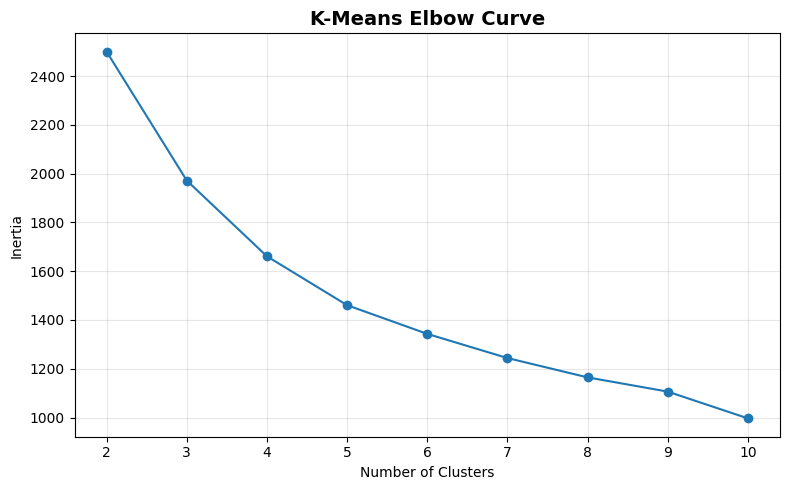

In [1416]:
# Plot K-Means elbow curve

plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["n_clusters"],
    kmeans_results_df["inertia"],
    marker="o"
)

plt.title("K-Means Elbow Curve", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

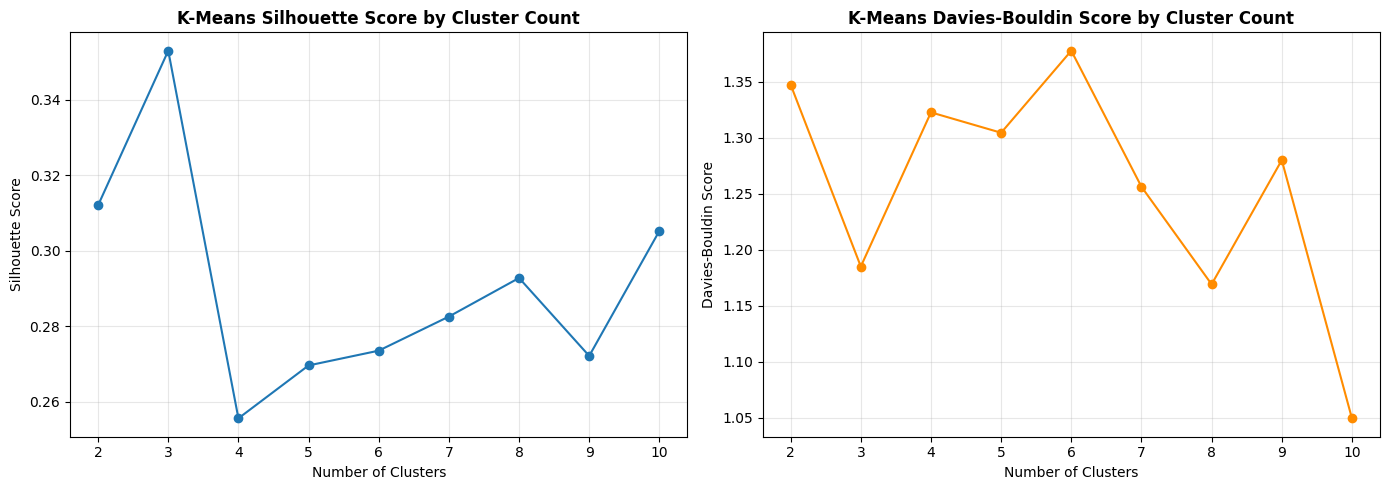

In [1417]:
# Plot internal validation metrics

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    kmeans_results_df["n_clusters"],
    kmeans_results_df["silhouette_score"],
    marker="o"
)
axes[0].set_title("K-Means Silhouette Score by Cluster Count", fontweight="bold")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    kmeans_results_df["n_clusters"],
    kmeans_results_df["davies_bouldin_score"],
    marker="o",
    color="darkorange"
)
axes[1].set_title("K-Means Davies-Bouldin Score by Cluster Count", fontweight="bold")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Davies-Bouldin Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1418]:
model_performance_explanations = """
The model performance results show that K-Means provides the most suitable clustering approach for
this product portfolio segmentation task.

K-Means with 3 clusters achieved the highest silhouette score at approximately 0.353, which means
it produced the strongest technical separation among the tested K-Means solutions. However, the
3-cluster solution also produced one very large cluster of 169 products. For this business use
case, that is less useful because a large catch-all segment makes it harder for merchandising and
promotion teams to design targeted actions.

K-Means with 5 clusters is selected as the business-preferred model. Although its silhouette score
is lower at approximately 0.270, it remains positive and produces more balanced cluster sizes, with
the smallest cluster containing 25 products and the largest containing 73 products.The silhouette
score of 0.270 falls below the conventional 0.3 threshold for strong
cluster separation. This is accepted because the business requirement is for actionable
and interpretable product segments, and the five-cluster solution provides clearly
differentiated commercial profiles that the three-cluster solution cannot. This makes the
segments more practical for product portfolio decisions because each cluster is large enough to
represent a meaningful group while still being specific enough to support differentiated promotion
strategies.

The elbow curve also supports k=5 as a reasonable choice using the 45-degree rule. The inertia
curve falls steeply from k=2 to k=5, showing that each additional cluster in this range still
creates a meaningful improvement in within-cluster compactness. After k=5, the curve begins to
flatten, meaning that extra clusters continue to reduce inertia but with smaller marginal gains.
This suggests that k=5 is a practical elbow point because it captures useful product structure
before the model starts adding complexity with less business value.

Mean Shift was included as a secondary comparison model. Some Mean Shift settings produced
competitive silhouette or Davies-Bouldin scores, but they also created very small clusters with
only 1 or 2 products. These micro-clusters are less suitable for business portfolio segmentation
because they isolate individual products rather than creating actionable product groups.

Overall, K-Means with 5 clusters provides the best trade-off between technical validity and
business usefulness. It is not selected only because of one metric; it is selected because it gives
a more actionable segmentation structure for margin-aware promotion decisions while maintaining
acceptable internal clustering performance.
"""

In [1419]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [1420]:
# Profile final selected K-Means k=5 clusters

final_model_name = "kmeans_k5"

final_model = model_results[final_model_name]["model"]
final_cluster_labels = model_results[final_model_name]["labels"]

clustered_products_df = profile_df.reset_index(drop=True).copy()
clustered_products_df["cluster"] = final_cluster_labels

clustered_model_input_df = X_train.reset_index(drop=True).copy()
clustered_model_input_df["cluster"] = final_cluster_labels

X_clustered = clustered_model_input_df.copy()

cluster_size_df = (
    clustered_products_df["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_size_df.columns = ["cluster", "product_count"]
cluster_size_df["product_share_pct"] = (
    cluster_size_df["product_count"] / len(clustered_products_df) * 100
).round(2)

cluster_size_df

,cluster,product_count,product_share_pct
0,0,25,9.84
1,1,49,19.29
2,2,73,28.74
3,3,52,20.47
4,4,55,21.65


In [1421]:
# Mean scaled feature profile by final cluster

cluster_feature_profile_df = (
    clustered_model_input_df
    .groupby("cluster")[features_list]
    .mean()
    .round(2)
)

cluster_feature_profile_df

,order_line_count,total_sales_value,avg_unit_price,gross_margin_pct,discounted_line_share,promotional_offer_count,max_eligible_discount_pct,promotional_order_line_share,max_actual_discount_pct,price_history_count,list_price_range,cost_history_count,standard_cost_range
cluster,,,,,,,,,,,,,
0,0.29,0.70,0.54,-0.47,2.51,0.80,0.95,2.07,2.35,-0.19,-0.47,-0.43,-0.33
1,0.80,-0.50,-1.23,1.31,0.00,0.57,0.43,-0.03,0.01,-0.16,-0.39,-0.20,-0.46
2,-0.90,-0.94,-0.42,0.42,-0.42,-0.82,-0.58,-0.41,-0.41,-0.24,-0.45,-0.50,-0.50
3,0.15,0.58,0.57,-0.84,-0.34,0.08,-0.01,-0.18,-0.29,1.21,1.72,1.63,1.79
4,0.21,0.82,0.87,-0.72,-0.27,0.14,-0.04,-0.19,-0.25,-0.59,-0.47,-0.51,-0.47


In [1422]:
# Category mix by cluster

cluster_category_profile_df = (
    clustered_products_df
    .groupby(["cluster", "category_name"])
    .size()
    .reset_index(name="product_count")
)

cluster_category_profile_df["cluster_share_pct"] = (
    cluster_category_profile_df
    .groupby("cluster")["product_count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

cluster_category_profile_df = cluster_category_profile_df.sort_values(
    ["cluster", "product_count"],
    ascending=[True, False]
)

cluster_category_profile_df

,cluster,category_name,product_count,cluster_share_pct
0,0,Bikes,22,88.00
1,0,Clothing,2,8.00
2,0,Components,1,4.00
3,1,Accessories,22,44.90
5,1,Components,14,28.57
4,1,Clothing,13,26.53
9,2,Components,59,80.82
8,2,Clothing,8,10.96
7,2,Bikes,4,5.48
6,2,Accessories,2,2.74


In [1423]:
# Strongest positive and negative signals by cluster

cluster_signal_df = (
    cluster_feature_profile_df
    .reset_index()
    .melt(
        id_vars="cluster",
        var_name="feature",
        value_name="mean_scaled_value"
    )
)

strong_cluster_signal_df = (
    cluster_signal_df[
        cluster_signal_df["mean_scaled_value"].abs() >= 0.50
    ]
    .sort_values(["cluster", "mean_scaled_value"], ascending=[True, False])
    .reset_index(drop=True)
)

strong_cluster_signal_df

,cluster,feature,mean_scaled_value
0,0,discounted_line_share,2.51
1,0,max_actual_discount_pct,2.35
2,0,promotional_order_line_share,2.07
3,0,max_eligible_discount_pct,0.95
4,0,promotional_offer_count,0.80
5,0,total_sales_value,0.70
6,0,avg_unit_price,0.54
7,1,gross_margin_pct,1.31
8,1,order_line_count,0.80
9,1,promotional_offer_count,0.57


In [1424]:
business_feature_pairs = [
    # Demand and revenue
    ("order_line_count", "total_sales_value"),

    # Price, revenue, and margin
    ("avg_unit_price", "gross_margin_pct"),
    ("total_sales_value", "gross_margin_pct"),
    ("avg_unit_price", "total_sales_value"),

    # Promotion eligibility vs actual promotion behaviour
    ("promotional_offer_count", "promotional_order_line_share"),
    ("max_eligible_discount_pct", "max_actual_discount_pct"),
    ("discounted_line_share", "promotional_order_line_share"),
    ("discounted_line_share", "max_actual_discount_pct"),

    # Promotion impact against margin and revenue
    ("promotional_order_line_share", "gross_margin_pct"),
    ("max_actual_discount_pct", "gross_margin_pct"),
    ("promotional_order_line_share", "total_sales_value"),

    # Historical price/cost movement
    ("price_history_count", "cost_history_count"),
    ("list_price_range", "standard_cost_range"),

    # Historical movement against margin and price
    ("list_price_range", "gross_margin_pct"),
    ("standard_cost_range", "gross_margin_pct"),
    ("standard_cost_range", "avg_unit_price")
]

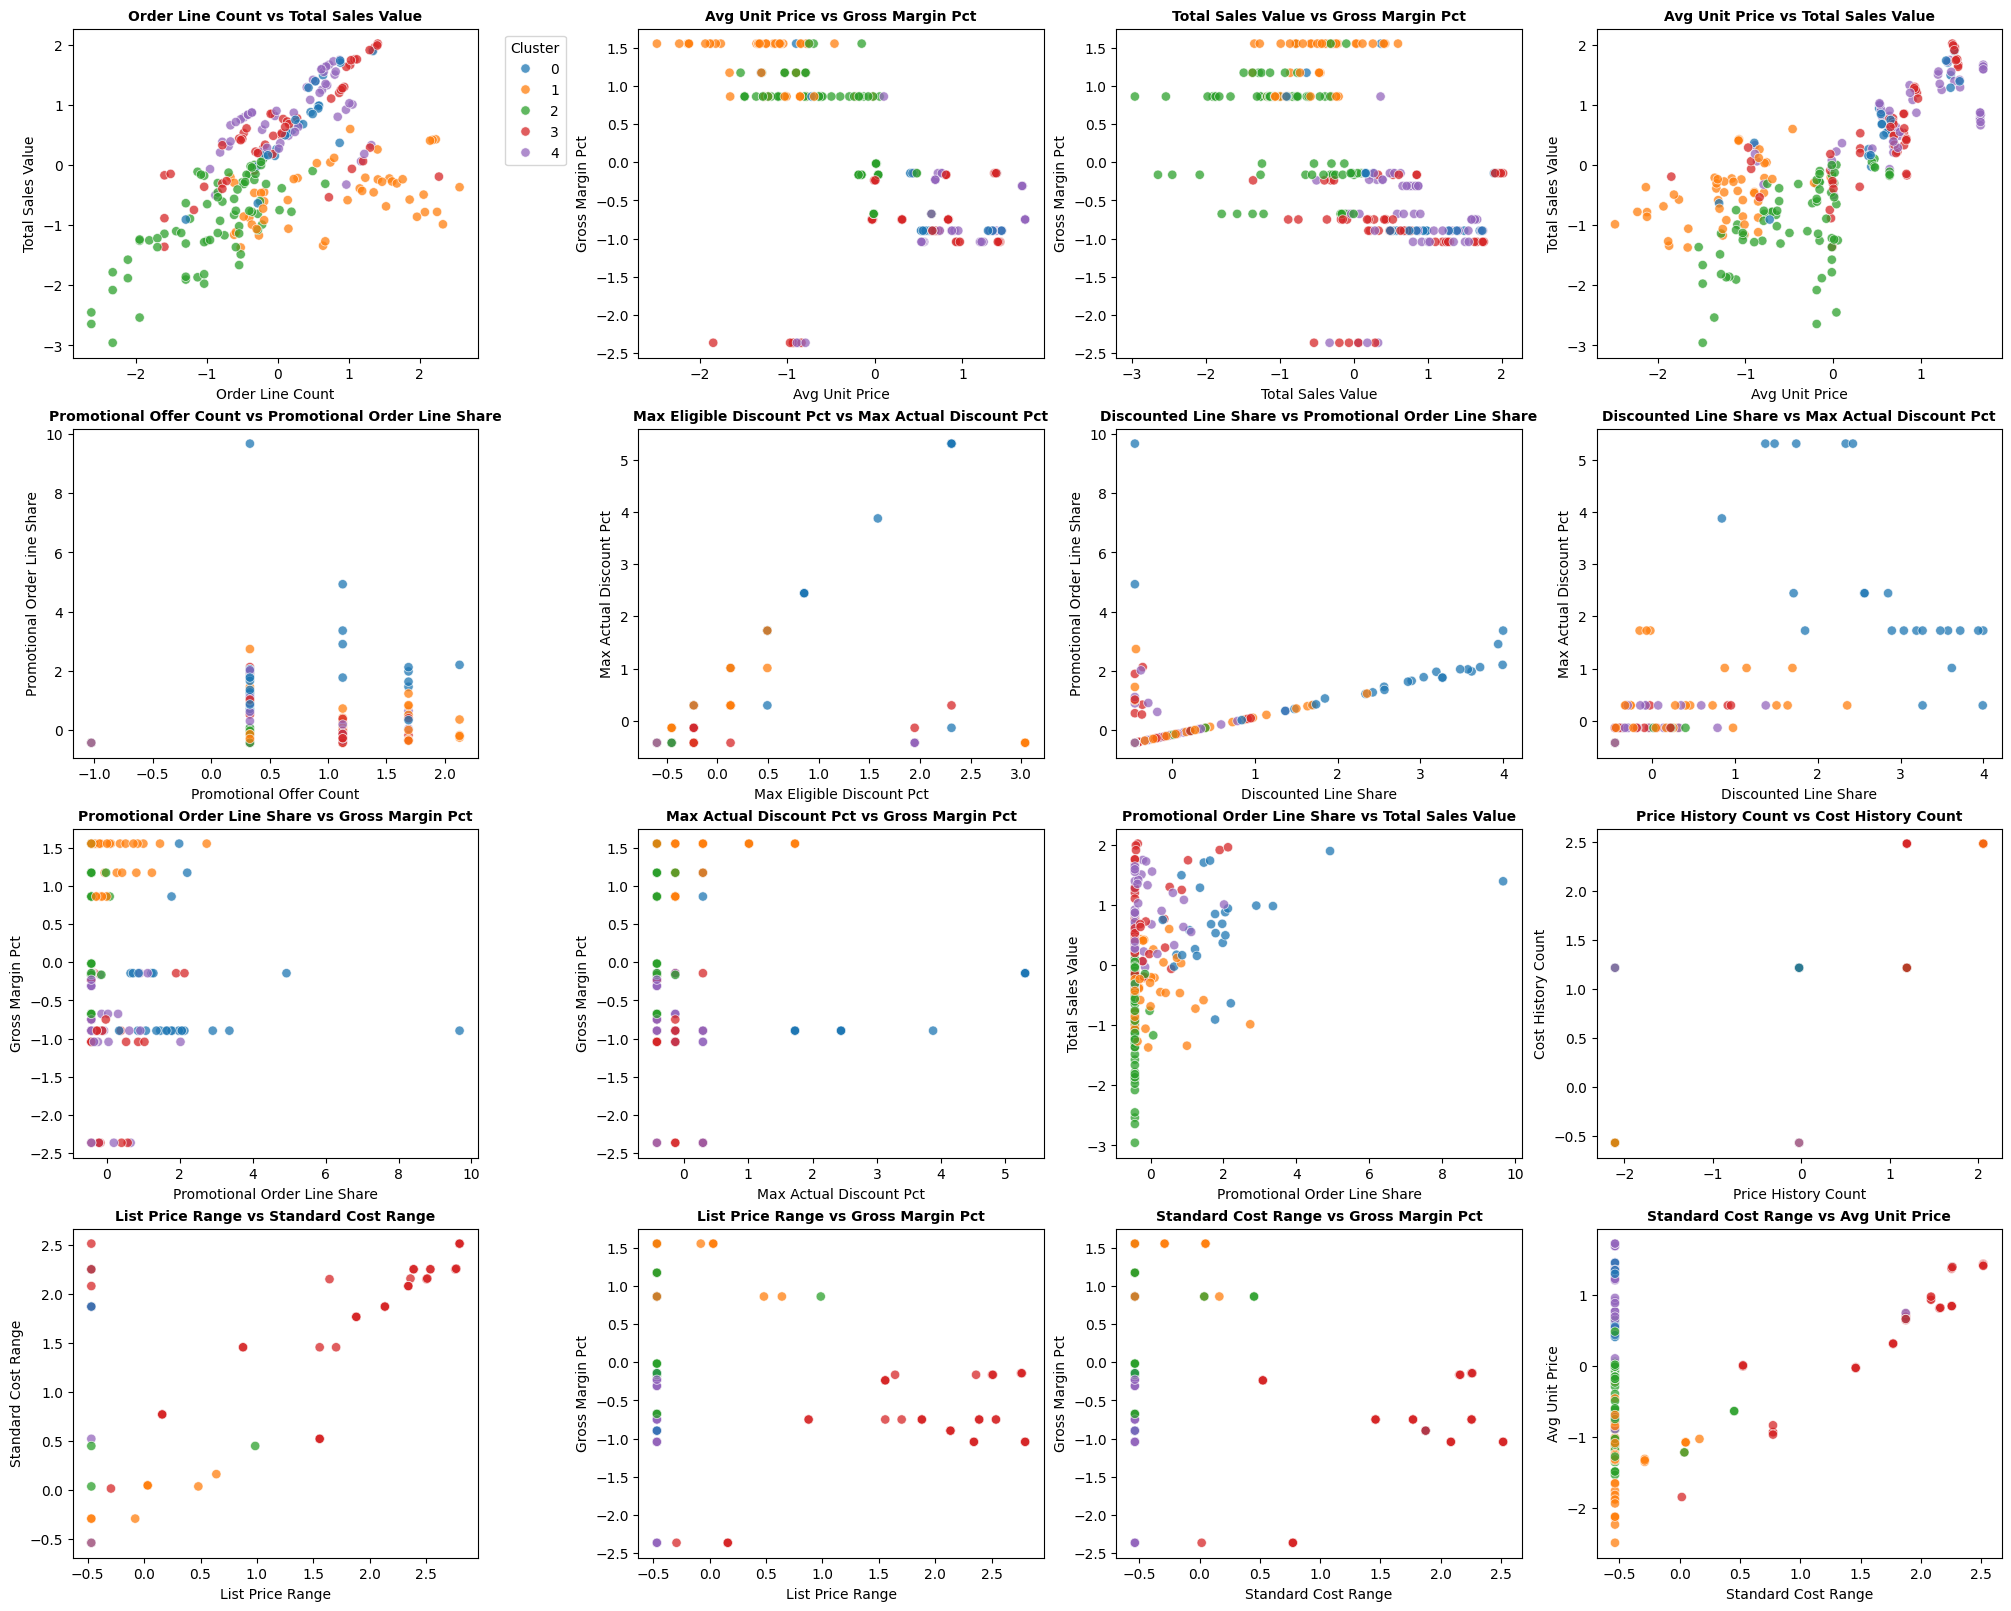

In [1425]:
import math
# Business-focused pair plots for final selected clustering features

ncols = 4
nrows = math.ceil(len(business_feature_pairs) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 4 * nrows),
    constrained_layout=True
)

axes = np.atleast_2d(axes).flatten()

for i, (x_feature, y_feature) in enumerate(business_feature_pairs):
    sns.scatterplot(
        data=X_clustered,
        x=x_feature,
        y=y_feature,
        hue="cluster",
        palette="tab10",
        alpha=0.75,
        s=45,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{x_feature.replace('_', ' ').title()} vs {y_feature.replace('_', ' ').title()}",
        fontsize=10,
        fontweight="bold"
    )
    axes[i].set_xlabel(x_feature.replace("_", " ").title())
    axes[i].set_ylabel(y_feature.replace("_", " ").title())

    if i == 0:
        axes[i].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        axes[i].legend_.remove()

for j in range(len(business_feature_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.show()

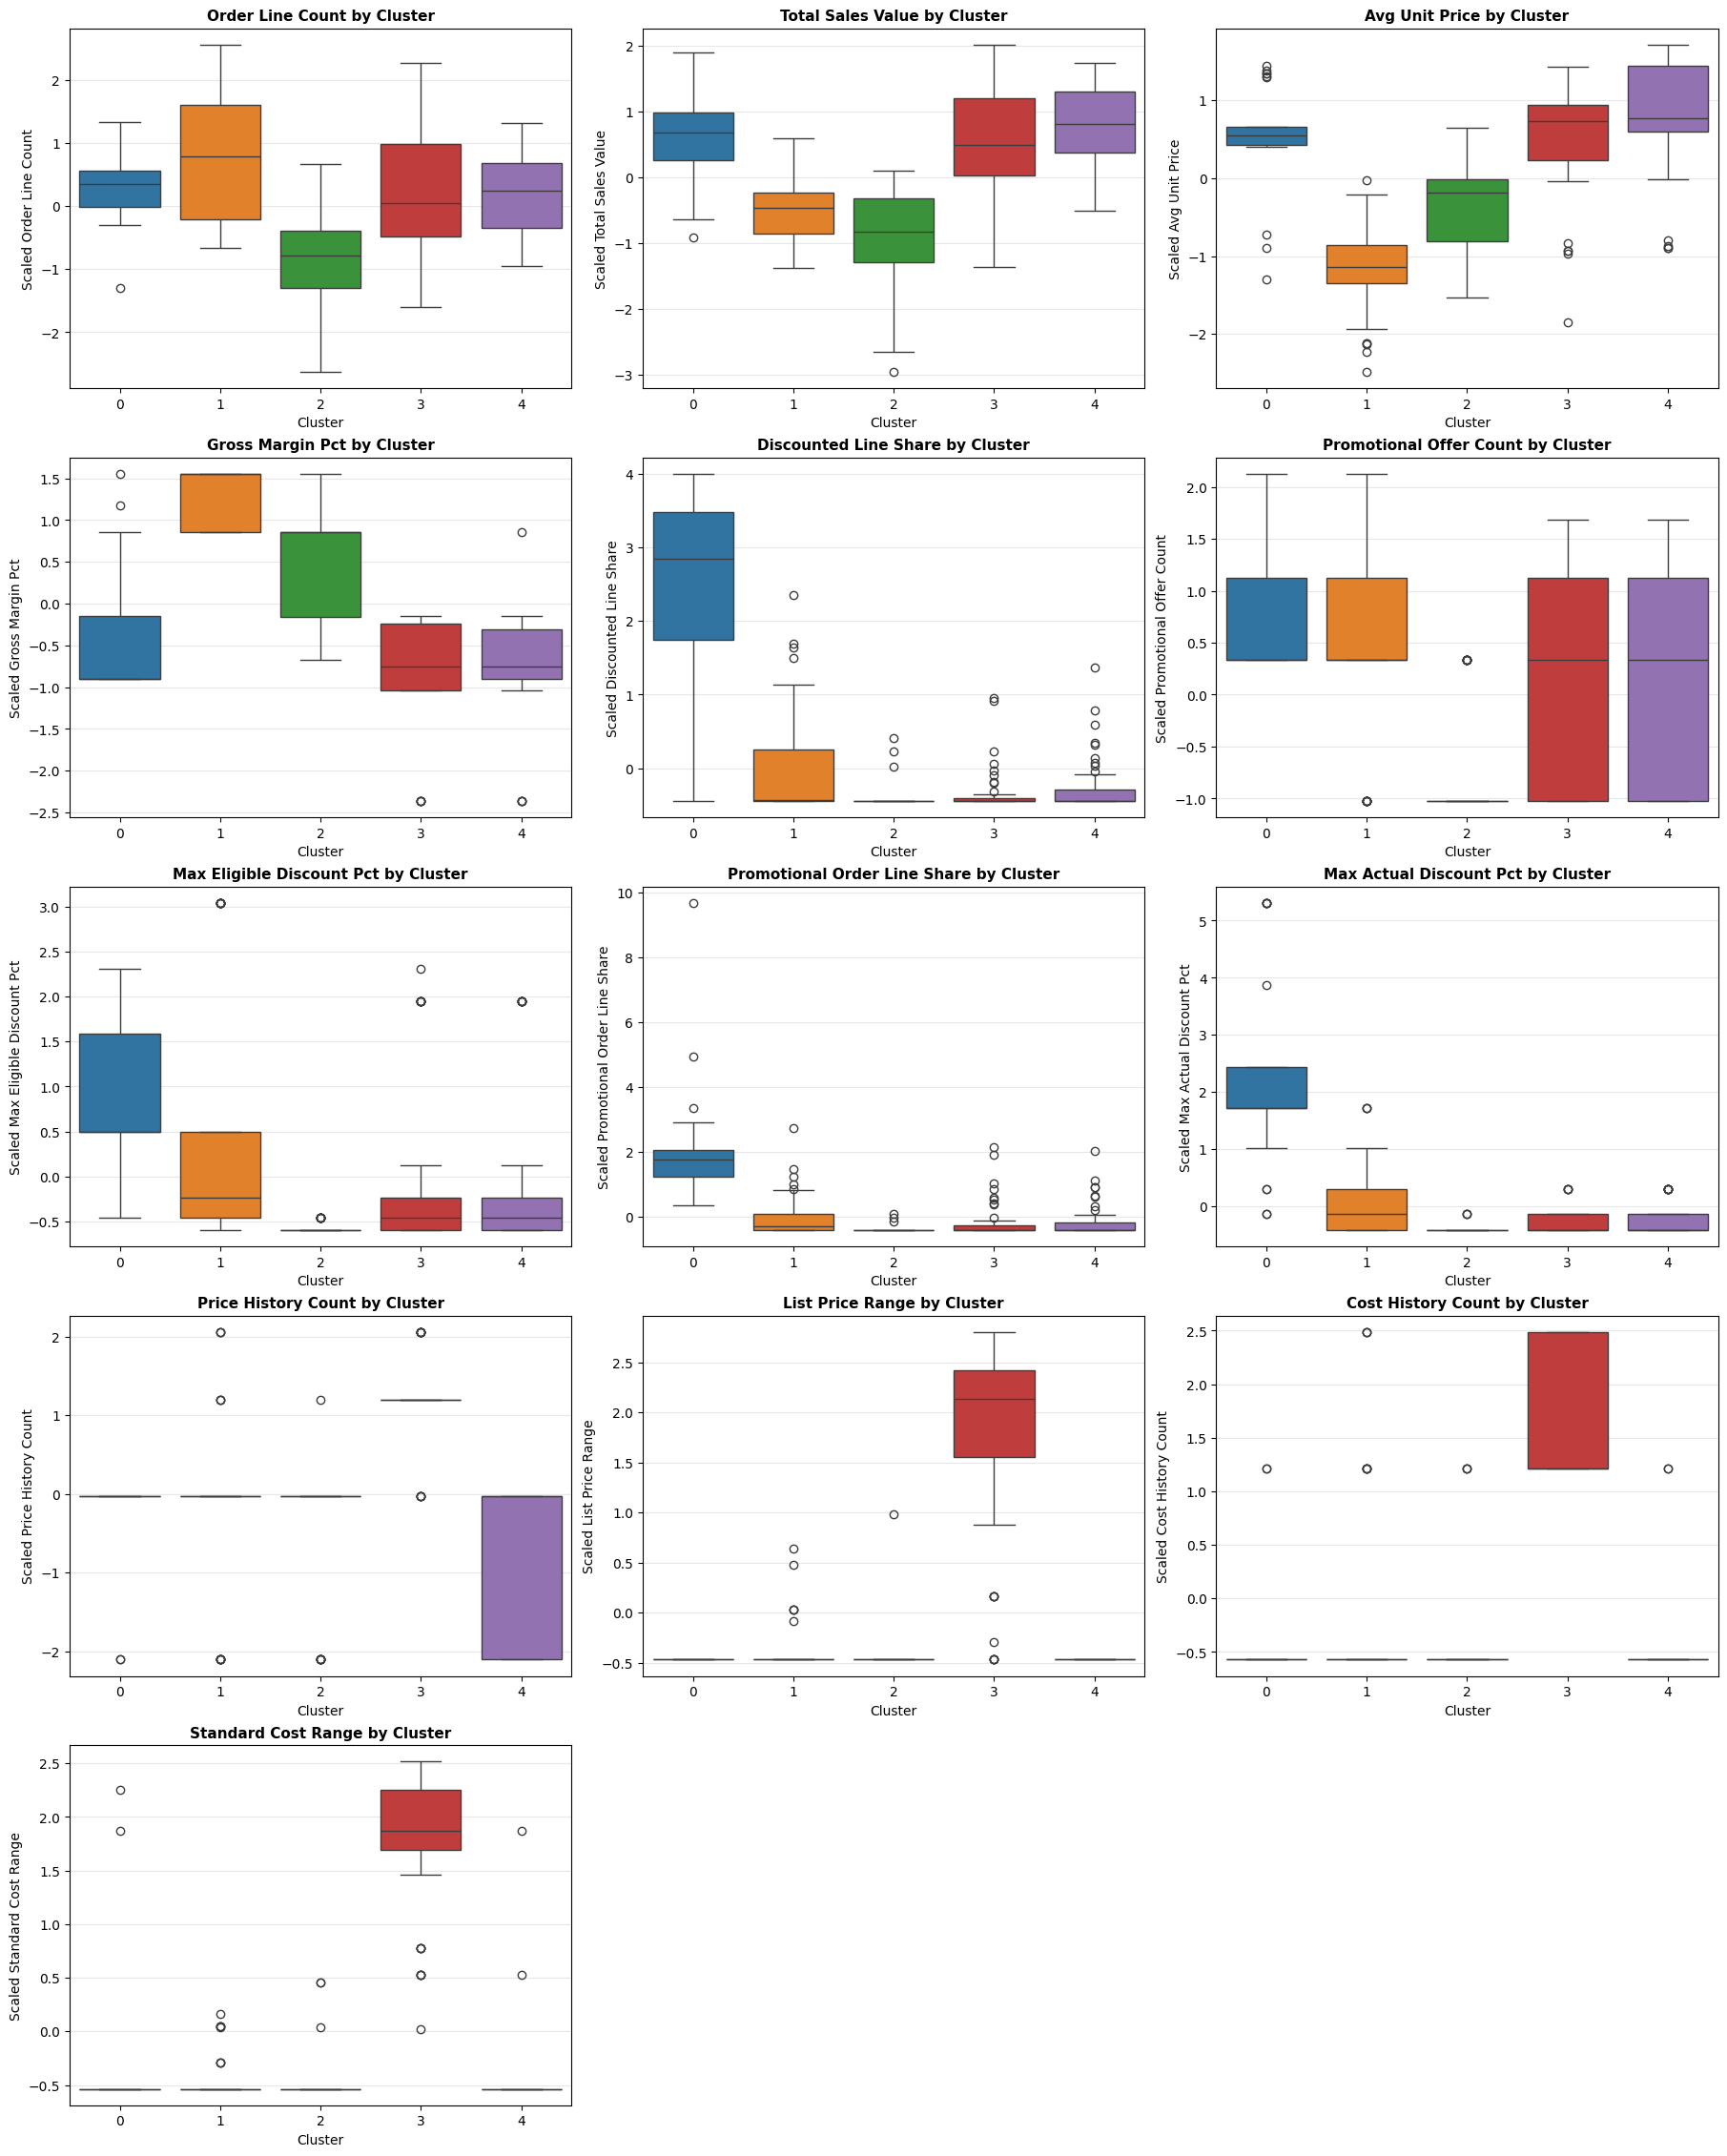

In [1426]:
# Univariate feature distributions by cluster

ncols = 3
nrows = math.ceil(len(features_list) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6 * ncols, 4.5 * nrows),
    constrained_layout=True
)

axes = np.atleast_2d(axes).flatten()

for i, feature in enumerate(features_list):
    sns.boxplot(
        data=X_clustered,
        x="cluster",
        y=feature,
        palette="tab10",
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature.replace('_', ' ').title()} by Cluster",
        fontsize=11,
        fontweight="bold"
    )
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(f"Scaled {feature.replace('_', ' ').title()}")
    axes[i].grid(axis="y", alpha=0.3)

for j in range(len(features_list), len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [1427]:
cluster_business_labels_df = pd.DataFrame({
    "cluster": [0, 1, 2, 3, 4],
    "business_label": [
        "Promotion-Risk Revenue Products",
        "High-Margin Frequent Sellers",
        "Low-Activity Review Products",
        "Price-Cost Volatility Products",
        "Premium Revenue Products"
    ],
    "recommended_action": [
        "Review promotion profitability and apply discount controls.",
        "Use for bundles, add-ons, and cross-sell without deep discounting.",
        "Review demand support, product placement, or range rationalisation.",
        "Monitor current cost and price movement before approving promotions.",
        "Protect price integrity and avoid broad discounting."
    ]
})

cluster_business_labels_df

,cluster,business_label,recommended_action
0,0,Promotion-Risk Revenue Products,Review promotion profitability and apply disco...
1,1,High-Margin Frequent Sellers,"Use for bundles, add-ons, and cross-sell witho..."
2,2,Low-Activity Review Products,"Review demand support, product placement, or r..."
3,3,Price-Cost Volatility Products,Monitor current cost and price movement before...
4,4,Premium Revenue Products,Protect price integrity and avoid broad discou...


In [1428]:
univariate_cluster_profile_insights = """
The univariate cluster profiles show that the five clusters separate products across the main
business dimensions needed for margin-aware promotion decisions. Each cluster exhibits a distinct
combination of demand activity, margin position, promotional exposure, and price/cost movement
that supports a targeted commercial strategy.

Cluster 0 is the strongest promotion-risk segment. It has the highest discounted line share,
maximum actual discount percentage, and promotional order line share of all five clusters, with
all three sitting well above the portfolio average. Maximum eligible discount percentage is also
above average, showing that these products have both promotion eligibility and high realised
discount exposure. Despite above-average total sales value and average unit price, gross margin
percentage is below the portfolio average. This suggests that revenue is being generated, but the
products may be vulnerable to margin erosion through promotional activity. The business should
review discount profitability, introduce discount guardrails, and require margin-floor approval
before increasing promotion depth for this cluster.

Cluster 1 is the high-margin, frequent-demand segment. It records the highest order line count and
the highest gross margin percentage of all five clusters, but has the lowest average unit price
and below-average total sales value. These products appear to sell frequently at lower price
points while maintaining strong relative margins. Discounted line share and maximum actual
discount percentage are low, suggesting that demand is not heavily dependent on realised
discounting. These products are suitable for cross-sell, add-on, and bundle strategies. The
business should avoid unnecessary deep discounting because the current profile already shows
healthy margin performance.

Cluster 2 is the low-activity segment. It records the lowest order line count and among the lowest
total sales value of any cluster. Average unit price is also low, suggesting that this is not a
premium niche segment. Promotional offer count and realised promotion measures are low, indicating
limited promotion exposure. Gross margin percentage is above the portfolio average, which is an
important signal: these products are not necessarily weak from a margin-rate perspective, but they
are not generating enough demand or revenue at scale. The business should assess whether targeted
demand support, better placement, or range rationalisation is the more appropriate response.

Cluster 3 is the price and cost movement risk segment. It has above-average total sales value
but below-average average unit price and gross margin percentage. The defining feature of this cluster
is historical movement: list price range, standard cost range, price history count, and cost
history count are all well above the other clusters. These products have experienced the most
price and cost changes, which makes margin-aware promotion decisions more complex. Any promotion
decision for Cluster 3 should be preceded by a review of current cost, recent price movement, and
minimum acceptable margin.

Cluster 4 is the premium revenue segment. It records the highest average unit price and strong
total sales value, suggesting that revenue is driven more by unit value than by transaction
frequency. Promotional intensity features are low, and historical price movement is also limited.
However, gross margin percentage is below the portfolio average, suggesting that the higher price
does not automatically translate into a high margin rate. These products may have a high cost base
or tighter relative margin. The recommended strategy is to protect price integrity, avoid broad
discounting, and use selective premium campaigns only where there is a clear commercial reason.

Overall, the profiles confirm that the five clusters represent distinct commercial roles across
demand activity, revenue scale, margin position, promotional exposure, and price/cost stability.
The separation is commercially interpretable and directly supports the use case of building a
margin-aware promotion decision framework for the retailer's product portfolio.
"""

In [1429]:
# Do not modify this code
print_tile(size="h3", key='univariate_cluster_profile_insights', value=univariate_cluster_profile_insights)

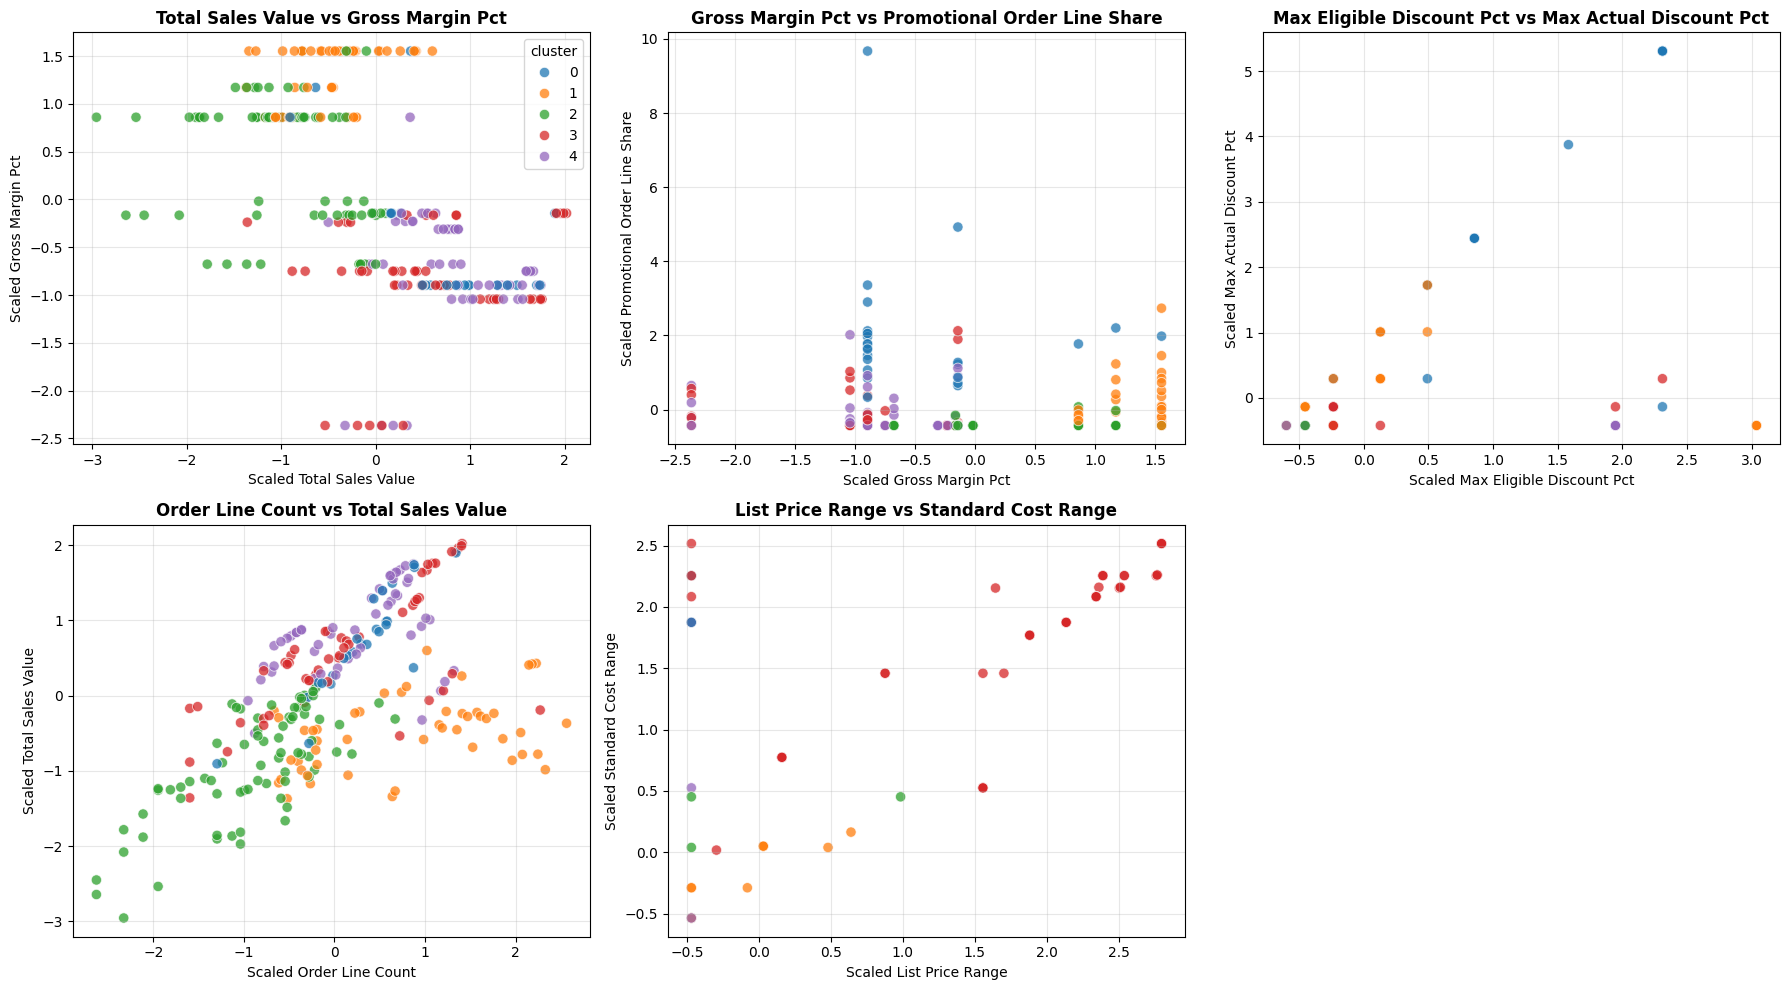

In [1430]:
essential_bivariate_pairs = [
    ("total_sales_value", "gross_margin_pct"),
    ("gross_margin_pct", "promotional_order_line_share"),
    ("max_eligible_discount_pct", "max_actual_discount_pct"),
    ("order_line_count", "total_sales_value"),
    ("list_price_range", "standard_cost_range")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (x_feature, y_feature) in enumerate(essential_bivariate_pairs):
    sns.scatterplot(
        data=X_clustered,
        x=x_feature,
        y=y_feature,
        hue="cluster",
        palette="tab10",
        alpha=0.75,
        s=55,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{x_feature.replace('_', ' ').title()} vs {y_feature.replace('_', ' ').title()}",
        fontweight="bold"
    )
    axes[i].set_xlabel(f"Scaled {x_feature.replace('_', ' ').title()}")
    axes[i].set_ylabel(f"Scaled {y_feature.replace('_', ' ').title()}")
    axes[i].grid(alpha=0.3)

    if i != 0:
        axes[i].legend_.remove()

for j in range(len(essential_bivariate_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [1431]:
bivariate_cluster_insights = """
The bivariate cluster profiles examine five commercially motivated feature pairs. Each pair was
selected to surface a specific business risk relevant to margin-aware promotion decisions. Together
they provide cross-cluster evidence that supports the univariate findings and deepens the
commercial interpretation.

1. Total Sales Value vs Gross Margin Percentage

This pair tests whether high-revenue products are also high-margin products. The analysis shows
they are not always aligned. Cluster 1 sits in the lower-revenue and high-margin area, confirming
that the portfolio's strongest margin group is not its strongest revenue group. Clusters 3 and 4
sit in the above-average revenue area but below the portfolio average for gross margin percentage,
meaning strong sales value does not automatically indicate a safe margin position. Cluster 0 also
has above-average sales value but below-average margin, and carries the highest promotional
exposure of all clusters. The business implication is that revenue rank alone is not a reliable
guide for promotion decisions. Margin must be assessed alongside revenue before any discount is
approved.

2. Gross Margin Percentage vs Promotional Order Line Share

This pair examines the relationship between promotion behaviour and margin position. Cluster 0 is
the clearest concern in this space because it combines above-average promotional order line share
with below-average gross margin percentage. This does not confirm that promotion caused the weaker
margin, but it shows that the products most exposed to promotional selling are associated with a
below-average margin position. Cluster 1 shows the opposite pattern: strong margin and very low
realised promotion usage. The contrast between these two clusters supports the business case for
differentiated promotion rules. Products that already have strong margin and low promotion
dependence should not be treated the same way as products with high promotion exposure and weaker
margin.

3. Maximum Eligible Discount Percentage vs Maximum Actual Discount Percentage

This pair compares what products are permitted to be discounted with what discount is actually
being applied. Cluster 0 stands out because it has both high promotion eligibility and the highest
realised discount depth of all five clusters. The other clusters show much lower realised discount
depth regardless of their eligibility level, which confirms that eligibility and realisation are
different signals. High eligibility does not automatically mean high discounting — but for Cluster
0, both are present simultaneously. The recommended action is to review discount ceilings for this
cluster, introduce margin-floor approval requirements, and monitor whether repeated discounting is
becoming a default behaviour rather than a targeted commercial decision.

4. Order Line Count vs Total Sales Value

This pair separates demand frequency from revenue contribution. Cluster 1 has the highest order
frequency but below-average total sales value, which is consistent with frequently purchased
lower-priced products. Clusters 3 and 4 have stronger total sales value with more moderate
frequency, suggesting revenue is driven by unit value rather than transaction volume. Cluster 2
sits in the low-frequency and low-revenue area, confirming its position as the lowest-activity
segment in the portfolio. Cluster 0 sits in a moderate position on both axes, which means its
high promotional exposure is not producing a demand or revenue premium large enough to justify
the margin cost.

5. List Price Range vs Standard Cost Range

This pair examines historical selling price and cost movement across the portfolio. Cluster 3
separates clearly from all other clusters with high list price range and high standard cost range,
confirming that it represents a distinct price and cost volatility segment. These products have
experienced both the widest price variation and the widest cost variation over their history,
which makes promotion decisions riskier because the margin position may shift after a discount is
agreed. All other clusters remain in the low-movement area on both dimensions, showing that
pricing and cost stability is the norm across the majority of the portfolio. Retaining both
features despite their correlation was useful because it made the volatility signature of Cluster
3 visible for business interpretation.

Overall, the bivariate analysis confirms that the clusters are commercially meaningful across
multiple dimensions. The separation is not driven by a single metric but reflects different
combinations of revenue, margin, promotion exposure, demand frequency, and price and cost
stability. This supports the use case of building a margin-aware promotion decision framework
where different product groups receive different commercial treatment.
"""

In [1432]:
# Do not modify this code
print_tile(size="h3", key='bivariate_cluster_insights', value=bivariate_cluster_insights)

In [1433]:
cluster_business_playbook_df = pd.DataFrame({
    "cluster": [0, 1, 2, 3, 4],
    "business_label": [
        "Promotion-Risk Revenue Products",
        "High-Margin Frequent Sellers",
        "Low-Activity Review Products",
        "Price-Cost Volatility Products",
        "Premium Revenue Products"
    ],
    "main_profile": [
        "High promotion usage, high discount depth, above-average sales value, but below-average margin.",
        "High margin percentage and frequent order activity, but lower unit price and lower total sales value.",
        "Low demand, low revenue, low promotion eligibility, and low realised promotion usage.",
        "High price and cost movement, above-average sales value, but below-average unit price and weak margin percentage.",
        "High unit price and strong sales value, with low promotion usage and limited historical movement."
    ],
    "recommended_business_action": [
        "Review promotion profitability, apply discount guardrails, and avoid unnecessary deep discounts.",
        "Use for bundles, add-ons, cross-sell, and low-risk campaign support without heavy discounting.",
        "Review product placement, demand support, stock holding, or range rationalisation.",
        "Check current cost and price movement before approving promotions; monitor margin risk closely.",
        "Protect price integrity and use selective premium campaigns rather than broad promotions."
    ],
    "risk_if_misused": [
        "Extra discounting could directly erode margin on already promotion-exposed products.",
        "Over-discounting may waste margin because these products already have strong relative margin.",
        "Ignoring this cluster may lead to dead stock or missed niche demand; over-promoting may waste spend.",
        "Promotion decisions based on outdated cost/price assumptions could damage profitability.",
        "Broad discounts could weaken premium positioning and reduce revenue quality."
    ]
})

cluster_business_playbook_df

,cluster,business_label,main_profile,recommended_business_action,risk_if_misused
0,0,Promotion-Risk Revenue Products,"High promotion usage, high discount depth, abo...","Review promotion profitability, apply discount...",Extra discounting could directly erode margin ...
1,1,High-Margin Frequent Sellers,High margin percentage and frequent order acti...,"Use for bundles, add-ons, cross-sell, and low-...",Over-discounting may waste margin because thes...
2,2,Low-Activity Review Products,"Low demand, low revenue, low promotion eligibi...","Review product placement, demand support, stoc...",Ignoring this cluster may lead to dead stock o...
3,3,Price-Cost Volatility Products,"High price and cost movement, above-average sa...",Check current cost and price movement before a...,Promotion decisions based on outdated cost/pri...
4,4,Premium Revenue Products,"High unit price and strong sales value, with l...",Protect price integrity and use selective prem...,Broad discounts could weaken premium positioni...


In [1434]:
business_impacts_explanations = """
The selected K-Means k=5 model supports the business objective by converting the sold product
portfolio into five actionable segments for margin-aware promotion decisions. The model helps the
business move away from broad discounting and toward different actions for products with different
margin, demand, promotion, and price/cost movement profiles.

Cluster 0, labelled Promotion-Risk Revenue Products, is the highest-risk promotion segment. These
products have the highest discount depth and the highest share of order lines on promotion across
all five clusters. The concern is that the gap between what these products are permitted to be
discounted and what is actually being applied has effectively closed — they are being discounted
close to their permitted ceiling with no structural floor remaining. Any further increase in
promotion depth will directly reduce gross margin without a clear revenue justification, because
the products already have above-average sales value and unit price. The business should not
approve automatic or deeper discounts for this cluster without a profitability review first.

Cluster 1, labelled High-Margin Frequent Sellers, is the portfolio's margin engine. These products
have the strongest gross margin percentage of all five clusters and the highest order frequency,
despite having the lowest average unit price. They sell regularly at modest price points and
customers are already buying at or near full price, which means promotional discounts are not
needed to drive demand. The business risk is applying unnecessary discounts to products that do
not need them, which would destroy margin that is currently self-sustaining. The recommended
approach is to grow this cluster through bundles, cross-sell, and add-on campaigns rather than
price reductions.

Cluster 2, labelled Low-Activity Review Products, has the weakest demand and lowest revenue of
all five clusters, with very little promotion activity. These products have a positive per-unit
margin, which means the issue is not that they are unprofitable — it is that not enough customers
are buying them. The business impact is two-sided. Ignoring this cluster may leave underperforming
products unmanaged and consuming shelf space or stock holding cost without return. On the other
hand, removing or heavily discounting them without a proper category review may harm niche
customer needs that are not visible in volume data alone. The recommended action is a targeted
placement and demand support review before any range rationalisation decision is made.

Cluster 3, labelled Price-Cost Volatility Products, has the highest historical price and cost
movement of all five clusters. These products have been repriced most frequently and their costs
have varied the most over time. The business risk is that a discount agreed today may become
unprofitable if the standard cost rises during the promotional window, because the cost floor is
not stable. These products should not receive promotional approval based on current margin data
alone. The business should check recent cost trend and supplier context before any promotion is
confirmed for this cluster.

Cluster 4, labelled Premium Revenue Products, has the highest average unit price and strong sales
value, with very low promotion usage and stable historical pricing. The counterintuitive finding
is that despite the premium price, gross margin percentage is below the dataset average, which
suggests the cost base for these products is also high. This makes discounting particularly
damaging — a price reduction on a product with a high cost base and already-compressed margin
percentage will erode profitability quickly. The business should protect list price for this
cluster and avoid broad discounting campaigns. Any commercial investment here should focus on
product quality, availability, and selective premium positioning rather than price reduction.

Overall, the model provides a decision-support structure rather than an automated promotion rule.
Because the silhouette score of 0.270 reflects moderate cluster separation, some products will
sit close to the boundary between two segments and should be reviewed individually rather than
treated solely on the basis of their cluster assignment. The cluster labels reflect historical
commercial behaviour and are not permanent — as sales patterns, costs, and promotion strategies
change over time, the model should be re-run to keep the segmentation current. The analysis also
covers only the 254 sold products with sufficient transaction history, so newly launched or
lightly-stocked products fall outside its scope. All promotion decisions based on cluster
membership should be validated against current margin data and reviewed by a category manager
before implementation.
"""

In [1435]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

### Experiment 1 Outcome

In [1436]:
experiment_1_outcome = "Hypothesis Confirmed"

In [1437]:
# Do not modify this code
print_tile(size="h2", key='experiment_1_outcome', value=experiment_1_outcome)

In [1438]:
experiment_results_1_explanations = """
The experiment confirms the hypothesis that sold products can be segmented into distinct and
actionable product portfolio groups using product-level demand, revenue, realised price, margin,
promotion eligibility, actual promotion usage, and historical price/cost movement features.

The final K-Means k=5 model produced five commercially interpretable product segments. Cluster 0
represents promotion-risk revenue products that need discount guardrails. Cluster 1 represents
high-margin frequent sellers that are suitable for bundles, add-ons, and cross-sell campaigns.
Cluster 2 represents low-activity review products that may need demand support, placement review,
or range rationalisation. Cluster 3 represents price-cost volatility products that require margin
monitoring before promotion approval. Cluster 4 represents premium revenue products where price
integrity should be protected.

A key insight from the experiment is that the technically highest-scoring clustering option is not
automatically the most useful business option. K-Means k=3 achieved the strongest silhouette score,
but it created one very large cluster that was less actionable for promotion planning. K-Means k=5
provided more balanced and business-specific segments, so it was selected as the business-preferred
solution.

Another important insight is that promotion eligibility and actual promotion usage are different
commercial signals. Products can be eligible for promotions but not heavily sold through
promotions, while other products can show high realised discounting and promotional order-line
usage. This difference is important because margin-aware promotion decisions need to consider what
the business could offer and what actually happens in transactions.

The current approach should be continued rather than treated as a dead end. The clusters are
interpretable, linked to the business objective, and support different recommended actions. The
next step is to validate the five cluster playbooks with merchandising and promotion stakeholders
before using them in campaign planning.

Recommended next experiments are ranked by expected business uplift. First, add customer breadth
features such as distinct_customer_count to measure whether product demand is broad or concentrated
across a small customer group. This is expected to provide high uplift because it adds a new
demand-risk dimension. Second, test additional clustering algorithms such as Agglomerative
Clustering or Gaussian Mixture Models to check whether non-spherical or hierarchical structures
produce stronger business interpretation. This is expected to provide medium uplift. Third, add
channel features such as online_order_share if the business wants channel-aware promotion planning.
This may provide medium uplift but should only be added if channel strategy becomes part of the
business objective.

For deployment, the recommended approach is a decision-support dashboard or reporting output rather
than an automated promotion engine. Each product should receive a cluster label, business segment
name, key profile indicators, and recommended action. The model should be reviewed with business
stakeholders, piloted on selected campaigns with holdout groups, monitored for margin and campaign
uplift, and refreshed periodically as new sales, price, cost, and promotion data becomes available.
"""

In [1439]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_1_explanations', value=experiment_results_1_explanations)

### Experiment 2 Outcome

In [1440]:
experiment_2_outcome = "Hypothesis Confirmed"

In [1441]:
# Do not modify this code
print_tile(size="h2", key='experiment_2_outcome', value=experiment_2_outcome)

In [1442]:
experiment_results_2_explanations = """
The experiment confirms the second hypothesis that a product-level clustering model can identify
4 to 6 stable and interpretable sold-product segments that are commercially distinct and useful for
margin-aware promotion decisions.

The selected K-Means k=5 model satisfies the expected cluster range because it produces five
segments. The cluster sizes are also viable for business use: the smallest cluster contains 25
products and the largest contains 73 products. This avoids both extremes of one overly broad
catch-all segment and very small micro-segments that would be difficult to operationalise.

The final segments are commercially distinct across the feature groups used in modelling. Cluster 0
is clearly separated by high promotion exposure and actual discount depth. Cluster 1 is separated
by high gross margin percentage and frequent order activity. Cluster 2 is separated by low demand,
low revenue, and low promotion activity. Cluster 3 is separated by high historical price and cost
movement with weaker margin percentage. Cluster 4 is separated by premium unit price and strong
sales value with limited promotional dependence.

The hypothesis is also confirmed from a business actionability perspective. Each cluster maps to a
different promotion or portfolio decision: Cluster 0 requires discount guardrails, Cluster 1 is
suited to bundles and cross-sell, Cluster 2 needs demand or range review, Cluster 3 requires
price-cost monitoring before promotions, and Cluster 4 should have premium price integrity
protected.

A key insight from this experiment is that interpretability and viable cluster size are as important
as internal clustering metrics. Although K-Means k=3 had the highest silhouette score, it produced
one large cluster of 169 products, which was less useful for targeted decision-making. K-Means k=5
provided a stronger business structure because the segments were more balanced and mapped more
clearly to different commercial actions.

The current approach should be pursued further. It is not a dead end because the model produces
segments that are technically valid enough, commercially interpretable, and directly linked to
promotion and margin decisions.

The highest-priority next experiment is stakeholder validation of the five segment playbooks with
merchandising, pricing, and promotion teams. This is expected to provide high business uplift
because it will test whether the recommended cluster actions are realistic and useful in actual
campaign planning. The second priority is adding customer breadth features such as
distinct_customer_count, which may improve the distinction between broad-demand and concentrated-
demand products. The third priority is testing an additional clustering method such as
Agglomerative Clustering or Gaussian Mixture Models to check whether a different cluster shape
improves interpretability.

If the business accepts the cluster profiles, the solution should be deployed as a decision-support
report or dashboard. The production output should include product_id, product name, cluster label,
business segment name, key feature profile, and recommended action. The model should be refreshed
periodically and monitored for segment drift, campaign uplift, discount depth, and gross margin
impact.
"""

In [1443]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_2_explanations', value=experiment_results_2_explanations)

In [1444]:
overall_experiment_conclusion = """
The modelling experiment shows that clustering is a suitable approach for the selected product
portfolio segmentation use case.

The comparison between K-Means and Mean Shift confirmed that the data contains meaningful product
group structure, but not every clustering method produced business-ready segments. Mean Shift was
useful as a comparison because it identified dense product groups without requiring a predefined
number of clusters. However, it also created very small clusters, which are difficult to use for
portfolio-level promotion planning.

K-Means provided the more practical final solution. Although k=3 achieved the strongest technical
separation, k=5 gave a better business structure because it produced five viable and interpretable
segments. These segments align directly with the business objective: identifying products that need
discount control, products suitable for bundles or cross-sell, products requiring demand or range
review, products needing price-cost monitoring, and premium products where price integrity should
be protected.

Overall, the experiment confirms that the final K-Means k=5 model can support margin-aware
promotion decisions. The model should be used as a decision-support tool, not an automated
promotion engine. The next step is to validate the segment playbooks with merchandising and
promotion stakeholders, test selected campaign actions with holdout groups, and monitor whether
the clusters help improve promotion efficiency and protect gross margin.
"""

In [1445]:
# Do not modify this code
print_tile(size="h2", key='overall_experiment_conclusion', value=overall_experiment_conclusion)